# Improving parselmouth's PyPI → conda name-mapping algorithm

*Forked from `name_mapper_comparison.ipynb`, which asked "how should the aggregator
combine grayskull, conda-lock, and parselmouth?" This notebook narrows the focus to
**parselmouth alone**: given its own raw evidence
(`data/parselmouth/mapping.sqlite3` → `pypi_conda_mapping`), what signals predict whether
its answer is right, and how could `score_evidence`
(`reroll/parselmouth_mapper/scoring.py`) be improved? Sections 1–8B are kept from the
original notebook as background/validation (they establish *that* candidate multiplicity,
not probability, is parselmouth's real risk signal); §9 and the aggregator-policy summary
were removed as out of scope for this notebook. New analysis is in §10.

**Parselmouth's current model** (`score_evidence`):

`probability = 0.95 × name_axis_factor × version_factor × contradiction_factor`

| axis | values → factor |
|---|---|
| `name_axis` | same → 1.00 · near → 0.75 · subpackage → 0.60 · unrelated → 0.40 |
| version state | agrees → 1.00 · no_signal → 0.80 · disagrees → 0.45 |
| contradictions (`vendored_only` + `claimed_by_other`, 0–2) | 0 → 1.00 · 1 → 0.35 · 2 → 0.05 |

None of these factors depend on **how many other conda packages also claim the same PyPI
name** — candidate-count ambiguity is a property of how many rows a `pypi_name` has in
`pypi_conda_mapping`, not an input to the formula at all. §10 quantifies the impact of
treating that count as a signal, starting with the two-candidate case, and looks at
whether the raw evidence columns already stored (`name_axis`, version corroboration,
`vendored_only`, `claimed_by_other`) hold further predictive signal the current formula
isn't using.

**Mapper reference** (unchanged from the original notebook):

| mapper | upstream data | probability semantics |
|---|---|---|
| `grayskull_mapper` | grayskull's hand-curated `config.yaml` exception table | always `1.0` (human-authored) |
| `conda_lock_mapper` | conda-forge autotick bot's `mappings/pypi` tables | `1.0` static override · `0.9` unambiguous · `0.6` ambiguous (HITS centrality) · `0.4` colliding spellings |
| `parselmouth_mapper` | parselmouth's `relations-v1` evidence table | `0.95 ×` name-axis `×` version-agreement `×` contradiction factors (`~0.02…0.95`); may return **several** candidates per name |

Data snapshot: universe is every distinct, canonicalized `project.name` in this repo's
`data/v.db` PyPI crawl (865,839 names); results are cached to
`data/name_mapper_candidates.parquet` (32,167 candidates); §10 queries
`data/parselmouth/mapping.sqlite3` directly instead of relying on that cache.

In [205]:
import sqlite3
import time
from pathlib import Path

import polars as pl
from IPython.display import display
from packaging.utils import canonicalize_name

from reroll.name_mapping import Candidate
from reroll.grayskull_mapper import grayskull_mapper
from reroll.conda_lock_mapper import conda_lock_mapper
from reroll.parselmouth_mapper import open_parselmouth_database, parselmouth_mapper


# Kernel cwd varies by how the notebook was opened (repo root vs. notebooks/); resolve
# the repo root by walking up until we find data/v.db, instead of assuming cwd.
def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "v.db").exists():
            return candidate
    raise FileNotFoundError(f"could not find data/v.db above {start}")


ROOT = _find_repo_root(Path.cwd())
DATA = ROOT / "data"
V_DB = DATA / "v.db"  # this repo's PyPI corpus; see the Makefile
PARSELMOUTH_DB = DATA / "parselmouth/mapping.sqlite3"

print("cwd:", ROOT)
import reroll

print("reroll from:", reroll.__file__)

cwd: /Users/anil/code/reroll-data
reroll from: /Users/anil/code/reroll/src/reroll/__init__.py


---
## 1. Data and method

**Universe.** Every distinct `project.name` in this repo's `v.db` PyPI index crawl,
canonicalized (`map_name` canonicalizes before dispatch, so the mappers see canonical
names).

**Independent opinions.** Each mapper is called with an empty candidate sequence —
exactly as if it were first in a chain — so every mapper's answer is its own, uninformed
by the others. A mapper returning the input unchanged means "no opinion"; anything it
appends is that mapper's candidate(s) for the name. All results land in one long-format
dataframe (`pypi_name, mapper, conda_name, probability`).

**Mapper construction** goes through reroll's public API, which handles its own data
acquisition:

- `grayskull_mapper()` — reads the `config.yaml` bundled with the installed grayskull. Offline.
- `conda_lock_mapper()` — fetches the autotick bot's three mapping tables through
  conda-lock's ETag-conditional cache (network on first run, cached afterwards).
- `parselmouth_mapper(conn)` — `open_parselmouth_database` downloads parselmouth's
  `relations.jsonl.gz` (ETag-conditional, ~88 MB) and rebuilds the local sqlite evidence
  db only when upstream changed.

**Questions, in order:** coverage (§2) → agreement (§3) → confidence thresholds (§4) →
conflict precedence (§5) → parselmouth standalone trust (§6) → multiplicity (§7) →
low-confidence tail (§8) → aggregator policy (§9).


In [206]:
t = time.time()
gsk = grayskull_mapper()
print(f"grayskull mapper built in {time.time() - t:.1f}s")

t = time.time()
clk = conda_lock_mapper()
print(f"conda-lock mapper built in {time.time() - t:.1f}s (includes cached downloads)")

t = time.time()
pconn = open_parselmouth_database(PARSELMOUTH_DB)
psm = parselmouth_mapper(pconn)
print(f"parselmouth db opened in {time.time() - t:.1f}s")
print(
    "pypi_conda_mapping rows:",
    pconn.execute("SELECT COUNT(*) FROM pypi_conda_mapping").fetchone()[0],
)

grayskull mapper built in 0.0s
conda-lock mapper built in 0.0s (includes cached downloads)
parselmouth db opened in 0.1s
pypi_conda_mapping rows: 21098


### Running the universe

The full run maps ~866k names through three mappers and is cached to
`data/name_mapper_candidates.parquet`; re-running this notebook loads the cache instead
of re-computing. Delete the parquet file to regenerate against fresher upstream data.


In [207]:
v = sqlite3.connect(V_DB)
names = sorted(
    {canonicalize_name(r[0]) for r in v.execute("SELECT DISTINCT name FROM project")}
)
v.close()
print(f"{len(names):,} canonicalized PyPI names")

CACHE = DATA / "name_mapper_candidates.parquet"
if CACHE.exists():
    candidates = pl.read_parquet(CACHE)
    print(f"loaded {candidates.height:,} cached candidates from {CACHE}")
else:
    t = time.time()
    rows = []
    for name in names:
        for mapper_name, m in (
            ("grayskull", gsk),
            ("conda_lock", clk),
            ("parselmouth", psm),
        ):
            for c in m(name, ()):
                rows.append((name, mapper_name, c.conda_name, c.probability))
    candidates = pl.DataFrame(
        rows, schema=["pypi_name", "mapper", "conda_name", "probability"], orient="row"
    )
    candidates.write_parquet(CACHE)
    print(f"{time.time() - t:.1f}s, {candidates.height:,} candidates -> {CACHE}")

candidates = candidates.with_columns(
    pl.col("conda_name")
    .map_elements(canonicalize_name, return_dtype=pl.String)
    .alias("conda_canon")
)

865,839 canonicalized PyPI names
loaded 32,187 cached candidates from /Users/anil/code/reroll-data/data/name_mapper_candidates.parquet


---
## 2. Coverage: who can answer what?

*Question: how much of PyPI can the aggregator answer at all, and which mapper carries
the load?*

The three mappers have wildly different scope by construction: grayskull is a curated
*exception* table (hundreds of entries), while conda-lock and parselmouth aim for full
conda-forge coverage. Overlap is computed on canonical PyPI names; conda-name agreement
canonicalizes both sides too (conda names are already lowercase, but `-`/`_` spelling varies).


In [208]:
by_mapper = (
    candidates.group_by("mapper")
    .agg(
        pl.col("pypi_name").n_unique().alias("names_covered"),
        pl.len().alias("candidates"),
    )
    .with_columns(
        (pl.col("names_covered") / len(names) * 100)
        .round(3)
        .alias("pct_of_pypi_universe")
    )
    .sort("names_covered", descending=True)
)
display(by_mapper)

# Per-name summary, reused throughout the rest of the report.
per_name = candidates.group_by("pypi_name").agg(
    pl.col("mapper").unique().sort().str.join("+").alias("sources"),
    pl.col("probability").max().alias("best_p"),
    pl.len().alias("n_candidates"),
)
print("\nwhich combination of mappers covers each name:")
display(
    per_name.group_by("sources")
    .agg(pl.len().alias("names"), pl.col("best_p").median().alias("median_best_p"))
    .sort("names", descending=True)
)

mapper,names_covered,candidates,pct_of_pypi_universe
str,u32,u32,f64
"""parselmouth""",19611,20249,2.265
"""conda_lock""",11802,11802,1.363
"""grayskull""",136,136,0.016



which combination of mappers covers each name:


sources,names,median_best_p
str,u32,f64
"""conda_lock+parselmouth""",11667,0.95
"""parselmouth""",7809,0.95
"""conda_lock+grayskull+parselmou…",83,1.0
"""grayskull+parselmouth""",52,1.0
"""conda_lock""",51,0.9
"""conda_lock+grayskull""",1,1.0


In [209]:
sets = {
    m: set(candidates.filter(pl.col("mapper") == m)["pypi_name"])
    for m in ("grayskull", "conda_lock", "parselmouth")
}
overlap_rows = []
for a, b in (
    ("conda_lock", "parselmouth"),
    ("grayskull", "conda_lock"),
    ("grayskull", "parselmouth"),
):
    inter = len(sets[a] & sets[b])
    overlap_rows.append((f"{a} ∩ {b}", inter, round(inter / len(sets[a] | sets[b]), 4)))
overlap_rows.append(("all three ∩", len(set.intersection(*sets.values())), None))
overlap_rows.append(
    ("any mapper (coverage of universe)", len(set.union(*sets.values())), None)
)
pl.DataFrame(overlap_rows, schema=["overlap", "names", "jaccard"], orient="row")

overlap,names,jaccard
str,i64,f64
"""conda_lock ∩ parselmouth""",11750,0.5976
"""grayskull ∩ conda_lock""",84,0.0071
"""grayskull ∩ parselmouth""",135,0.0069
"""all three ∩""",83,null
"""any mapper (coverage of univer…",19663,null


**What this means for the aggregator:**

- **Parselmouth is the coverage backbone** (19,591 names); conda-lock is nearly a strict
  subset of it (only **52** conda-lock-only names), and grayskull adds **zero** unique
  names (its one entry outside parselmouth is covered by conda-lock).
- **Union coverage is 19,643 names — 2.27% of PyPI.** Everything else has no conda-forge
  counterpart and falls through to the caller's identity/default policy.
- **≥ 2 mappers answer for 11,803 names** — these get the corroboration treatment in §3.
  The remaining 7,840 covered names are single-source (7,789 parselmouth-only, 51
  conda-lock-only) — for those, confidence thresholds are the only gate (§4, §8).


---
## 3. Agreement: is a second mapper's match decisive?

*Question: where ≥2 mappers answer, how often do they name the same conda package — and
is agreement strong enough to end the decision there?*

Each mapper is reduced to its **top candidate** per name (highest probability, ties
broken by order returned). Then, per mapper pair, agreement is measured over the names
both cover.


In [210]:
top = candidates.sort("probability", descending=True).unique(
    subset=["pypi_name", "mapper"], keep="first"
)
wide = top.pivot(index="pypi_name", on="mapper", values="conda_canon")
wide_p = top.pivot(index="pypi_name", on="mapper", values="probability")

pairs = [
    ("conda_lock", "parselmouth"),
    ("grayskull", "conda_lock"),
    ("grayskull", "parselmouth"),
]
rows = []
for a, b in pairs:
    both = wide.filter(pl.col(a).is_not_null() & pl.col(b).is_not_null())
    agree = both.filter(pl.col(a) == pl.col(b)).height
    rows.append(
        (
            f"{a} vs {b}",
            both.height,
            agree,
            both.height - agree,
            round(agree / both.height, 4),
        )
    )

all3 = wide.drop_nulls()
unanimous = all3.filter(
    (pl.col("grayskull") == pl.col("conda_lock"))
    & (pl.col("conda_lock") == pl.col("parselmouth"))
).height
rows.append(
    (
        "all three unanimous",
        all3.height,
        unanimous,
        all3.height - unanimous,
        round(unanimous / all3.height, 4),
    )
)

pl.DataFrame(
    rows, schema=["pair", "both_cover", "agree", "disagree", "agree_rate"], orient="row"
)

pair,both_cover,agree,disagree,agree_rate
str,i64,i64,i64,f64
"""conda_lock vs parselmouth""",11750,11722,28,0.9976
"""grayskull vs conda_lock""",84,84,0,1.0
"""grayskull vs parselmouth""",135,115,20,0.8519
"""all three unanimous""",83,74,9,0.8916


**Finding: agreement is the norm, and two-source agreement is as close to ground truth as
this data offers.** Conda-lock × parselmouth agree on 99.75% of shared names; the two
curated sources (grayskull, conda-lock) *never* disagree (0/84). The residual
disagreements are not randomly distributed — they cluster exactly where curated overrides
live, which is the subject of §5.

**Policy consequence: any conda name backed by ≥2 mappers can be accepted without
further checks.**


---
## 4. Confidence structure: where should the cutoff be?

*Question: what probability threshold should the aggregator require of a single-source
answer?*

The mappers' probability scales are not comparable — conda-lock uses four documented
tiers, parselmouth a multiplicative evidence score quantized around 0.95, grayskull a
constant 1.0. So instead of calibrating across mappers, measure *observed agreement with
an independent source* as a function of confidence.


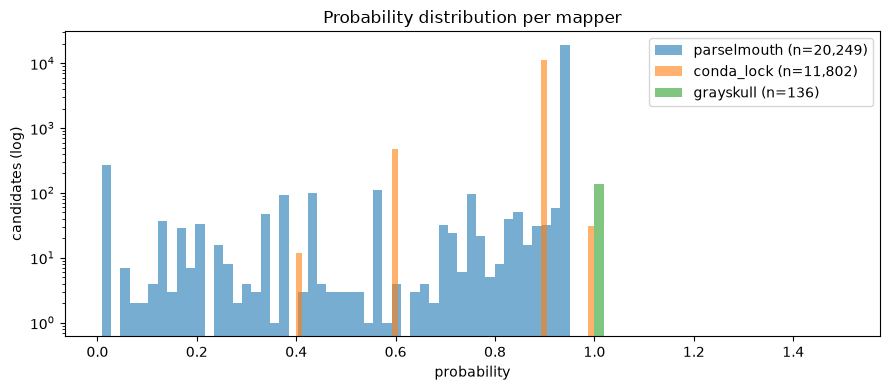

shape: (4, 2)
┌─────────────┬───────┐
│ probability ┆ len   │
│ ---         ┆ ---   │
│ f64         ┆ u32   │
╞═════════════╪═══════╡
│ 1.0         ┆ 31    │
│ 0.9         ┆ 11288 │
│ 0.6         ┆ 471   │
│ 0.4         ┆ 12    │
└─────────────┴───────┘


In [211]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for m, color in (("parselmouth", "C0"), ("conda_lock", "C1"), ("grayskull", "C2")):
    probs = candidates.filter(pl.col("mapper") == m)["probability"]
    ax.hist(probs, bins=50, alpha=0.6, label=f"{m} (n={len(probs):,})", color=color)
ax.set_yscale("log")
ax.set_xlabel("probability")
ax.set_ylabel("candidates (log)")
ax.set_title("Probability distribution per mapper")
ax.legend()
plt.tight_layout()
plt.show()

# conda-lock's four documented tiers:
print(
    candidates.filter(pl.col("mapper") == "conda_lock")
    .group_by("probability")
    .agg(pl.len())
    .sort("probability", descending=True)
)

In [212]:
def pair_frame(a, b):
    ca = top.filter(pl.col("mapper") == a).select(
        "pypi_name",
        conda_a=pl.col("conda_canon"),
        p_a=pl.col("probability"),
        raw_a=pl.col("conda_name"),
    )
    cb = top.filter(pl.col("mapper") == b).select(
        "pypi_name",
        conda_b=pl.col("conda_canon"),
        p_b=pl.col("probability"),
        raw_b=pl.col("conda_name"),
    )
    return ca.join(cb, on="pypi_name").with_columns(
        (pl.col("conda_a") == pl.col("conda_b")).alias("agree")
    )


cl_ps = pair_frame("conda_lock", "parselmouth")

print("parselmouth's top-candidate confidence x agreement with conda-lock:")
display(
    cl_ps.with_columns(
        pl.col("p_b")
        .cut(
            [0.3, 0.5, 0.7, 0.8, 0.949],
            labels=["<0.3", "0.3-0.5", "0.5-0.7", "0.7-0.8", "0.8-<0.95", "0.95"],
        )
        .alias("psm_top_p")
    )
    .group_by("psm_top_p")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("psm_top_p")
)

print("\nconda-lock's tier x agreement with parselmouth:")
display(
    cl_ps.with_columns(
        pl.col("p_a")
        .cut(
            [0.5, 0.95],
            labels=["0.4/0.6 (ambiguous)", "0.9 (unambiguous)", "1.0 (static)"],
        )
        .alias("lock_tier")
    )
    .group_by("lock_tier")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("lock_tier")
)

parselmouth's top-candidate confidence x agreement with conda-lock:



conda-lock's tier x agreement with parselmouth:


psm_top_p,n,agree_n,agree_rate
enum,u32,u32,f64
"""<0.3""",7,7,1.0
"""0.3-0.5""",34,34,1.0
"""0.5-0.7""",25,25,1.0
"""0.7-0.8""",76,75,0.9868
"""0.8-<0.95""",38,37,0.9737
"""0.95""",11570,11544,0.9978



conda-lock's tier x agreement with parselmouth:


lock_tier,n,agree_n,agree_rate
enum,u32,u32,f64
"""0.4/0.6 (ambiguous)""",12,7,0.5833
"""0.9 (unambiguous)""",11708,11693,0.9987
"""1.0 (static)""",30,22,0.7333


In [213]:
# Disagreements are not a low-confidence phenomenon: they sit at parselmouth's MAXIMUM
# confidence, inside conda-lock's curated tiers.
dis = cl_ps.filter(~pl.col("agree"))
print(f"disagreements: {dis.height} of {cl_ps.height:,} shared names")
display(
    dis.with_columns(
        pl.col("p_a")
        .cut([0.5, 0.95], labels=["0.4/0.6", "0.9", "1.0 (static)"])
        .alias("lock_tier"),
        (pl.col("p_b") >= 0.9).alias("psm_ge_0.9"),
    )
    .group_by("lock_tier", "psm_ge_0.9")
    .agg(pl.len().alias("n"))
    .sort("lock_tier", "psm_ge_0.9")
)

# High-confidence conflicts: both sides >= 0.9 and different answers -- the cases
# confidence alone cannot settle.
hi = cl_ps.filter((pl.col("p_a") >= 0.9) & (pl.col("p_b") >= 0.9) & ~pl.col("agree"))
print(
    f"\nhigh-confidence conflicts (both >= 0.9, different answers): "
    f"{hi.height} of {cl_ps.height:,} shared names"
)

disagreements: 28 of 11,750 shared names



high-confidence conflicts (both >= 0.9, different answers): 21 of 11,750 shared names


lock_tier,psm_ge_0.9,n
enum,bool,u32
"""0.4/0.6""",true,5
"""0.9""",false,2
"""0.9""",true,13
"""1.0 (static)""",true,8



high-confidence conflicts (both >= 0.9, different answers): 21 of 11,750 shared names


**Threshold guidance from the data:**

- **≥ 0.9 → accept a single-source answer.** 98.2% of covered names (19,287/19,643) have
  a best answer ≥ 0.9; where an independent check exists, agreement at that level is
  ≥ 99.7%.
- **0.5–0.9 → require a second mapper.** Few names live here (94); corroborated
  low-confidence answers turn out to be reliable (§8) — but uncorroborated ones are
  unverifiable.
- **< 0.5 → defer.** Only 262 covered names have nothing ≥ 0.5 anywhere (median best
  0.38); no mapper pair ever corroborates down there.
- **Do not use confidence to arbitrate *between* mappers.** Disagreement does not rise as
  parselmouth's confidence falls — every sub-0.6 parselmouth answer that conda-lock could
  check matched it (57/57). The conflicts instead sit at parselmouth's *maximum*
  confidence, inside conda-lock's curated static tier. Probability ranks candidates
  *within* a mapper; *between* mappers, source class decides (§5).


---
## 5. Conflicts: which mapper takes precedence?

*Question: when mappers name different conda packages, who wins — and can confidence
settle it?*

Conflicts are rare (29 between conda-lock and parselmouth, out of 11,750 shared names),
but they concentrate in two distinct classes with opposite resolutions: **curated
overrides**, where the evidence-based mapper is wrong by construction, and **genuine
ambiguity**, where no curated opinion exists to arbitrate.


In [214]:
gsk_top = top.filter(pl.col("mapper") == "grayskull").select(
    "pypi_name", g=pl.col("conda_canon")
)

g_ps = pair_frame("grayskull", "parselmouth")
g_cl = pair_frame("grayskull", "conda_lock")
print(
    f"grayskull  x conda_lock  : {g_cl.height:4d} shared, "
    f"{g_cl.filter(~pl.col('agree')).height} conflicts"
)
print(
    f"grayskull  x parselmouth : {g_ps.height:4d} shared, "
    f"{g_ps.filter(~pl.col('agree')).height} conflicts"
)
print(
    f"conda_lock x parselmouth : {cl_ps.height:4d} shared, "
    f"{cl_ps.filter(~pl.col('agree')).height} conflicts"
)

# Third-mapper arbitration on names all three cover: when parselmouth disagrees with a
# curated source, which side does the OTHER curated source back?
all3 = wide.drop_nulls().rename(
    {"grayskull": "g", "conda_lock": "l", "parselmouth": "p"}
)
g_vs_p = all3.filter(pl.col("g") != pl.col("p"))
print(
    f"\nall-three-covered names where grayskull != parselmouth: {g_vs_p.height} "
    f"-> conda-lock backs grayskull "
    f"{g_vs_p.filter(pl.col('l') == pl.col('g')).height}/{g_vs_p.height}"
)

# High-confidence conflicts (both sides >= 0.9): split into curated overrides vs
# genuine ambiguity, using grayskull's presence as the tiebreaker signal.
hi_cls = hi.join(gsk_top, on="pypi_name", how="left").with_columns(
    pl.when(pl.col("g").is_null())
    .then(pl.lit("genuine ambiguity (no grayskull opinion)"))
    .otherwise(pl.lit("curated override (grayskull backs conda-lock)"))
    .alias("class")
)
print(f"\nhigh-confidence conflicts (both >= 0.9): {hi_cls.height}")
display(hi_cls.group_by("class").agg(pl.len().alias("n")))
display(
    hi_cls.select("pypi_name", "raw_a", "p_a", "raw_b", "p_b", "class")
    .rename(
        {"raw_a": "conda_lock", "p_a": "p_lock", "raw_b": "parselmouth", "p_b": "p_psm"}
    )
    .sort("class", "pypi_name")
)

# Is the curated answer at least visible to parselmouth, as a runner-up candidate?
psm_cands = (
    candidates.filter(pl.col("mapper") == "parselmouth")
    .group_by("pypi_name")
    .agg(pl.col("conda_canon").alias("psm_all"))
)
gd = (
    g_ps.filter(~pl.col("agree"))
    .join(psm_cands, on="pypi_name", how="left")
    .with_columns(
        pl.col("psm_all").list.contains(pl.col("conda_a")).alias("gsk_answer_in_psm")
    )
)
hd = hi.join(psm_cands, on="pypi_name", how="left").with_columns(
    pl.col("psm_all").list.contains(pl.col("conda_a")).alias("lock_answer_in_psm")
)
print(
    f"\ngrayskull conflicts where grayskull's answer is among parselmouth's candidates: "
    f"{gd['gsk_answer_in_psm'].sum()}/{gd.height}"
)
print(
    f"high-confidence conflicts where conda-lock's answer is among parselmouth's "
    f"candidates: {hd['lock_answer_in_psm'].sum()}/{hd.height}"
)

grayskull  x conda_lock  :   84 shared, 0 conflicts
grayskull  x parselmouth :  135 shared, 20 conflicts
conda_lock x parselmouth : 11750 shared, 28 conflicts

all-three-covered names where grayskull != parselmouth: 9 -> conda-lock backs grayskull 9/9

high-confidence conflicts (both >= 0.9): 21


class,n
str,u32
"""curated override (grayskull ba…",8
"""genuine ambiguity (no grayskul…",13



grayskull conflicts where grayskull's answer is among parselmouth's candidates: 17/20
high-confidence conflicts where conda-lock's answer is among parselmouth's candidates: 18/21


pypi_name,conda_lock,p_lock,parselmouth,p_psm,class
str,str,f64,str,f64,str
"""build""","""python-build""",1.0,"""build""",0.95,"""curated override (grayskull ba…"
"""cockroachdb""","""cockroachdb-python""",0.9,"""cockroachdb""",0.95,"""curated override (grayskull ba…"
"""cufflinks""","""python-cufflinks""",0.9,"""cufflinks-py""",0.95,"""curated override (grayskull ba…"
"""duckdb""","""python-duckdb""",1.0,"""duckdb""",0.95,"""curated override (grayskull ba…"
"""matplotlib""","""matplotlib-base""",1.0,"""matplotlib""",0.95,"""curated override (grayskull ba…"
…,…,…,…,…,…
"""qtconsole""","""qtconsole-base""",0.9,"""qtconsole""",0.95,"""genuine ambiguity (no grayskul…"
"""ribs""","""pyribs-base""",0.9,"""pyribs""",0.95,"""genuine ambiguity (no grayskul…"
"""sagemaker""","""sagemaker-python-sdk""",0.9,"""sagemaker""",0.95,"""genuine ambiguity (no grayskul…"



grayskull conflicts where grayskull's answer is among parselmouth's candidates: 17/20
high-confidence conflicts where conda-lock's answer is among parselmouth's candidates: 18/21


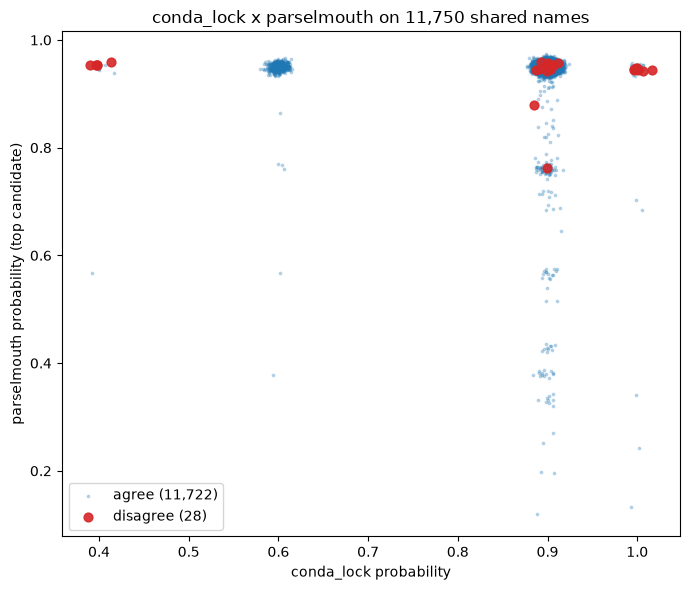

In [215]:
# Scatter: each shared name's two probabilities, colored by agreement.
# (Jittered slightly: probabilities are quantized, so points stack.)
import numpy as np

rng = np.random.default_rng(0)
x = cl_ps["p_a"].to_numpy() + rng.normal(0, 0.006, cl_ps.height)
y = cl_ps["p_b"].to_numpy() + rng.normal(0, 0.006, cl_ps.height)
agree = cl_ps["agree"].to_numpy()
n_agree, n_disagree = int(agree.sum()), int((~agree).sum())

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x[agree], y[agree], s=3, alpha=0.25, c="C0", label=f"agree ({n_agree:,})")
ax.scatter(
    x[~agree], y[~agree], s=40, alpha=0.9, c="C3", label=f"disagree ({n_disagree})"
)
ax.set_xlabel("conda_lock probability")
ax.set_ylabel("parselmouth probability (top candidate)")
ax.set_title(f"conda_lock x parselmouth on {cl_ps.height:,} shared names")
ax.legend()
plt.tight_layout()
plt.show()

**Precedence finding: source class decides; probability never does.**

- The two curated sources are perfectly consistent (grayskull × conda-lock: **0
  conflicts in 84** shared names), and in every three-way arbitration conda-lock backs
  grayskull (**9/9**).
- Parselmouth argues for the wrong side at its own **maximum** confidence (0.95) in all
  20 grayskull conflicts and all 8 conda-lock-static conflicts — e.g. `duckdb` →
  `python-duckdb`, `dask` → `dask-core`, `xtb` → `xtb-python`. These conflicts exist
  *because* the automatic answer is wrong; no probability threshold fixes that. (The
  curated answer is usually visible to parselmouth as a lower-ranked candidate — 17/20 —
  so the evidence isn't absent, it's just outranked by a stronger, wrong signal.)
- The remaining 15 high-confidence conflicts (conda-lock 0.9 vs. parselmouth 0.95, no
  curated opinion — e.g. `pyfai`: pyfai-base vs. pyfai) are genuinely ambiguous: the data
  cannot arbitrate them. They are 0.13% of shared names; resolve them deterministically
  and log the decision for manual review.

**Order: grayskull → conda-lock static → two-source vote → confidence.**


---
## 6. Can parselmouth be trusted by itself?

*Question: ignoring the static/curated mappings (which exist precisely because the
automatic tools get those particular names wrong), how often does parselmouth agree with
the other tools in the overlap space — and how does that depend on its probability and
its candidate count?*

Parselmouth-only names are 40% of coverage (7,789), so its standalone reliability sets
the practical error rate of the aggregator. Test: take names both parselmouth and
conda-lock cover, excluding every name a curated source touches (conda-lock's static
tier, any grayskull entry) — the space where both remaining mappers are answering from
evidence, not human override — and measure agreement as parselmouth's confidence and
candidate count vary.


In [216]:
noncurated = cl_ps.filter(
    (pl.col("p_a") < 1.0) & (~pl.col("pypi_name").is_in(list(sets["grayskull"])))
)
print(
    f"non-curated overlap: {noncurated.height:,} names; agreement "
    f"{noncurated['agree'].sum():,}/{noncurated.height:,} = {noncurated['agree'].mean():.4f}"
)

print("\nby parselmouth's top-candidate probability:")
display(
    noncurated.with_columns(
        pl.col("p_b")
        .cut(
            [0.3, 0.5, 0.7, 0.8, 0.949],
            labels=["<0.3", "0.3-0.5", "0.5-0.7", "0.7-0.8", "0.8-<0.95", "0.95"],
        )
        .alias("psm_p")
    )
    .group_by("psm_p")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        (1 - pl.col("agree").mean()).round(4).alias("disagree_rate"),
    )
    .sort("psm_p")
)

psm_ncand = (
    candidates.filter(pl.col("mapper") == "parselmouth")
    .group_by("pypi_name")
    .agg(pl.len().alias("n_cand"))
)
print("by parselmouth's candidate count:")
display(
    noncurated.join(psm_ncand, on="pypi_name")
    .with_columns(
        pl.when(pl.col("n_cand") == 1)
        .then(pl.lit("1"))
        .when(pl.col("n_cand") == 2)
        .then(pl.lit("2"))
        .otherwise(pl.lit("3+"))
        .alias("psm_candidates")
    )
    .group_by("psm_candidates")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        (1 - pl.col("agree").mean()).round(4).alias("disagree_rate"),
    )
    .sort("psm_candidates")
)

print("joint view -- candidate count x top probability >= 0.9:")
display(
    noncurated.join(psm_ncand, on="pypi_name")
    .with_columns(
        (pl.col("n_cand") > 1).alias("multi_candidate"),
        (pl.col("p_b") >= 0.9).alias("p_ge_0.9"),
    )
    .group_by("multi_candidate", "p_ge_0.9")
    .agg(pl.len().alias("n"), pl.col("agree").mean().round(4).alias("agree_rate"))
    .sort("multi_candidate", "p_ge_0.9")
)

print("the 17 residual conflicts (all remaining non-curated disagreements):")
display(
    noncurated.filter(~pl.col("agree"))
    .join(psm_ncand, on="pypi_name")
    .select("pypi_name", "raw_a", "p_a", "raw_b", "p_b", "n_cand")
    .rename(
        {"raw_a": "conda_lock", "p_a": "p_lock", "raw_b": "parselmouth", "p_b": "p_psm"}
    )
    .sort("p_psm", descending=True)
)

non-curated overlap: 11,653 names; agreement 11,637/11,653 = 0.9986

by parselmouth's top-candidate probability:


by parselmouth's candidate count:


psm_p,n,agree_n,disagree_rate
enum,u32,u32,f64
"""<0.3""",5,5,0.0
"""0.3-0.5""",30,30,0.0
"""0.5-0.7""",19,19,0.0
"""0.7-0.8""",74,73,0.0135
"""0.8-<0.95""",37,36,0.027
"""0.95""",11488,11474,0.0012


by parselmouth's candidate count:


joint view -- candidate count x top probability >= 0.9:


...

joint view -- candidate count x top probability >= 0.9:


the 17 residual conflicts (all remaining non-curated disagreements):


multi_candidate,p_ge_0.9,n,agree_rate
bool,bool,u32,f64
false,false,145,0.9931
false,true,11349,1.0
true,false,2,0.5
true,true,157,0.9108


the 17 residual conflicts (all remaining non-curated disagreements):


pypi_name,conda_lock,p_lock,parselmouth,p_psm,n_cand
str,str,f64,str,f64,u32
"""sagemaker""","""sagemaker-python-sdk""",0.9,"""sagemaker""",0.95,2
"""ribs""","""pyribs-base""",0.9,"""pyribs""",0.95,2
"""devtools""","""python-devtools""",0.9,"""devtools""",0.95,2
"""asap3""","""asap""",0.4,"""asap3""",0.95,2
"""spyder""","""spyder-base""",0.9,"""spyder""",0.95,2
…,…,…,…,…,…
"""primesieve""","""python-primesieve""",0.9,"""primesieve""",0.95,2
"""pyrad-mch""","""pyrad_arm""",0.4,"""pyrad_mch""",0.95,2
"""pyhyperscattering""","""pyhyperscattering-base""",0.9,"""pyhyperscattering""",0.95,2


**Verdict: yes — when parselmouth returns exactly one candidate, trust it at essentially
any confidence; when it returns several, get a vote.**

- **Single candidate, p ≥ 0.9: 11,384/11,384 agreement — no observed failures.** This is
  the cell that carries the 7,441 parselmouth-only names sitting at 0.95.
- **Probability barely predicts error.** Every checkable sub-0.9 band agrees at 98.5% or
  better, and everything below 0.7 matched 100% of the time (small n, but consistent).
  The only meaningful driver of disagreement is candidate count, not probability.
- **Multiplicity is the real risk signal.** Two candidates → 10.6% disagreement
  (127/142 agree); 3+ → 5.9% (16/17 agree) — vs. 0.01% for single-candidate names. Nearly
  all residual conflicts are multi-candidate names where conda-lock prefers a
  split/minimal package (`pandera-core`, `lit-nlp`, `python-devtools`) and parselmouth's
  top pick is the metapackage.
- Caveat: agreement between two independent evidence pipelines is a proxy for
  correctness, not proof — but it's the strongest proxy available short of manual audit,
  and a 0.15% residual disagreement rate bounds the plausible error for single-candidate,
  high-confidence, uncorroborated parselmouth answers.


---
## 7. Parselmouth multiplicity: is the top candidate enough?

*Question: when parselmouth offers several candidates, does taking only its
max-probability one lose anything?*

§6 showed multiplicity is where parselmouth's risk concentrates. Here: on
multi-candidate names where conda-lock also answers, does conda-lock back parselmouth's
top candidate — or a runner-up?


In [217]:
ps_multi = (
    candidates.filter(pl.col("mapper") == "parselmouth")
    .group_by("pypi_name")
    .agg(pl.len().alias("n"), pl.col("probability").max().alias("top_p"))
    .filter(pl.col("n") > 1)
)
print(f"parselmouth multi-candidate names: {ps_multi.height:,}")
display(ps_multi.group_by("n").agg(pl.len().alias("names")).sort("n"))

lock_top = top.filter(pl.col("mapper") == "conda_lock").select(
    "pypi_name", lock=pl.col("conda_canon")
)
chk = (
    candidates.filter(
        (pl.col("mapper") == "parselmouth")
        & pl.col("pypi_name").is_in(ps_multi["pypi_name"].implode())
    )
    .group_by("pypi_name")
    .agg(pl.col("conda_canon").alias("all"), pl.col("probability").alias("ps"))
    .join(lock_top, on="pypi_name", how="inner")
    .with_columns(
        pl.struct(["all", "ps", "lock"])
        .map_elements(
            lambda r: (
                "lock backs psm top"
                if r["lock"] == r["all"][r["ps"].index(max(r["ps"]))]
                else (
                    "lock backs psm runner-up"
                    if r["lock"] in r["all"]
                    else "lock backs neither"
                )
            ),
            return_dtype=pl.String,
        )
        .alias("relation")
    )
)
print(f"\n...of which conda-lock also answers: {chk.height}")
display(
    chk.group_by("relation").agg(pl.len().alias("names")).sort("names", descending=True)
)

parselmouth multi-candidate names: 500


n,names
u32,u32
2,427
3,45
4,14
5,8
6,2
7,1
11,2
12,1



...of which conda-lock also answers: 186


relation,names
str,u32
"""lock backs psm top""",160
"""lock backs psm runner-up""",24
"""lock backs neither""",2


**Finding: keep parselmouth's full candidate list.** Conda-lock backs parselmouth's top
candidate in 159/186 multi-candidate names, but a **runner-up in 25 (13.4%)** — an
aggregator that collapses each mapper down to its max-probability candidate forfeits
those 25 correct answers. The vote rule (§9, rule 3) therefore counts *all* of a mapper's
candidates, not just its top: a second mapper's support promotes a parselmouth runner-up
above its own top candidate.


---
## 8. The low-confidence tail: when is "an answer" worse than none?

*Question: can low-confidence results be trusted, and in which cases?*

For every covered name: what's the best probability available, and from which
combination of mappers? "Low-confidence-only" names are those where every candidate is
below 0.5 — the aggregator technically has an answer, but should it use it?


In [218]:
print("best-available-probability distribution across all 19,643 covered names:")
display(
    pl.DataFrame(
        [
            ("< 0.5", per_name.filter(pl.col("best_p") < 0.5).height),
            (
                "0.5 - < 0.9",
                per_name.filter(
                    (pl.col("best_p") >= 0.5) & (pl.col("best_p") < 0.9)
                ).height,
            ),
            (">= 0.9", per_name.filter(pl.col("best_p") >= 0.9).height),
        ],
        schema=["best_p_band", "names"],
        orient="row",
    )
)

LOW = 0.5
low_only = per_name.filter(pl.col("best_p") < LOW)
print(f"\nnames where EVERY candidate is < {LOW}: {low_only.height:,}")
display(
    low_only.group_by("sources").agg(
        pl.len().alias("names"),
        pl.col("best_p").median().round(3).alias("median_best_p"),
    )
)

print("\nof the 7,789 parselmouth-only names, probability band:")
display(
    per_name.filter(pl.col("sources") == "parselmouth")
    .with_columns(
        pl.col("best_p")
        .cut(
            [0.3, 0.5, 0.6, 0.7, 0.8, 0.949],
            labels=[
                "<=0.3",
                "0.3-0.5",
                "0.5-0.6",
                "0.6-0.7",
                "0.7-0.8",
                "0.8-<0.95",
                "0.95",
            ],
        )
        .alias("band")
    )
    .group_by("band")
    .agg(pl.len().alias("names"))
    .sort("band")
)

best-available-probability distribution across all 19,643 covered names:



names where EVERY candidate is < 0.5: 273



of the 7,789 parselmouth-only names, probability band:


best_p_band,names
str,i64
"""< 0.5""",273
"""0.5 - < 0.9""",275
""">= 0.9""",19115


sources,names,median_best_p
str,u32,f64
"""parselmouth""",273,0.38


band,names
enum,u32
"""<=0.3""",83
"""0.3-0.5""",190
"""0.5-0.6""",42
"""0.6-0.7""",39
"""0.7-0.8""",68
"""0.8-<0.95""",218
"""0.95""",7169


**Low-confidence guidance:**

- **Uncorroborated, < 0.5 → don't answer.** 262 names (1.3% of covered names, all
  parselmouth-only, median best probability 0.38) have nothing better anywhere. There is
  no second opinion to check them against, and §6 offers no evidence either way at this
  probability with no corroboration.
- **Corroborated low confidence is fine.** §4's threshold sweep already showed every
  parselmouth answer below 0.6 that conda-lock could check, matched (57/57). Low
  probability from one evidence-based mapper, backed by a second mapper's independent
  agreement, is trustworthy — the low score just reflects thin evidence *within* that
  mapper's model, not doubt about the answer itself.
- **Single-source ≥ 0.9 is fine without corroboration** — 95.5% of parselmouth-only names
  (7,441/7,789) clear this bar, and §6 found no observed failures for single-candidate
  answers at this level.
- Practically: **1.3% of covered names (262) should be deferred outright**; the rest of
  the low-confidence space (94 names, 0.5–0.9) is small enough that requiring
  corroboration there costs little coverage.


---
## 8B. Outlier-corrected re-analysis: does removing curated overrides change the picture?

*Question: §3–§8 measured parselmouth's agreement with conda-lock using conda-lock's raw
probabilities, including its `1.0` "static override" tier — rows a human explicitly
hand-corrected *because the automatic answer was wrong*. Grayskull's entire table is the
same kind of thing: a hand-written exception list, not a scored guess. Every one of those
rows is, by construction, a case where a naive/automatic guess (which is exactly what
parselmouth produces) had to be overridden. Scoring parselmouth against those rows measures
how often humans intervene, not how good parselmouth's own confidence signal is.*

*This section removes that penalty and asks the same questions again: identify every PyPI
name that is (a) in grayskull's table, or (b) has a conda-lock static (`p=1.0`) row, and for
those names only, drop parselmouth's candidate rows entirely — as if parselmouth had never
answered for them — while leaving grayskull's and conda-lock's own rows untouched.*

*Nothing in §2 (coverage, overlap) is recomputed or superseded by this section — those
figures describe the real, unmodified data and remain the headline coverage numbers. This
section builds a second, parallel view purely to re-ask "when parselmouth and conda-lock
both have an unforced opinion, do they agree, and does parselmouth's own confidence track
that agreement?"*

In [219]:
# Outlier set: any name a human had to hand-fix in *either* curated source.
grayskull_names = sets["grayskull"]
conda_lock_static_names = set(
    top.filter((pl.col("mapper") == "conda_lock") & (pl.col("probability") == 1.0))[
        "pypi_name"
    ]
)
outlier_names = grayskull_names | conda_lock_static_names
psm_outlier_overlap = outlier_names & sets["parselmouth"]

print(f"grayskull-curated names: {len(grayskull_names):,}")
print(f"conda-lock static-override names: {len(conda_lock_static_names):,}")
print(
    f"union (outlier names): {len(outlier_names):,} "
    f"(overlap between the two: {len(grayskull_names & conda_lock_static_names)})"
)
print(
    f"...of which parselmouth also answers (rows to drop): {len(psm_outlier_overlap):,}"
)

# Drop parselmouth's rows for outlier names only. Grayskull's and conda-lock's rows for
# those same names are untouched -- this dataframe is candidates as-if parselmouth had
# never seen the names a human already had to correct.
candidates_adj = candidates.filter(
    ~(
        (pl.col("mapper") == "parselmouth")
        & pl.col("pypi_name").is_in(list(psm_outlier_overlap))
    )
)
print(
    f"\ncandidates: {candidates.height:,} rows -> candidates_adj: {candidates_adj.height:,} rows "
    f"({candidates.height - candidates_adj.height:,} parselmouth rows dropped, "
    f"{100 * (candidates.height - candidates_adj.height) / candidates.height:.2f}% of all candidates)"
)

grayskull-curated names: 136
conda-lock static-override names: 31
union (outlier names): 150 (overlap between the two: 17)
...of which parselmouth also answers (rows to drop): 149

candidates: 32,187 rows -> candidates_adj: 31,973 rows (214 parselmouth rows dropped, 0.66% of all candidates)


### Checking the simplifying assumption: does grayskull ever add information conda-lock doesn't already have?

If grayskull and conda-lock never conflict wherever both cover a name, grayskull can be
folded into "curated" without a separate arbitration path, and the only pairing worth
analyzing in detail is parselmouth vs. conda-lock's non-static tier.

In [220]:
# g_cl (grayskull x conda_lock pair_frame) was already built in §5 -- reuse it.
n_gsk = len(sets["grayskull"])
print(f"grayskull names: {n_gsk}")
print(
    f"...covered by conda-lock too: {g_cl.height} ({g_cl.height / n_gsk:.1%} of grayskull)"
)
print(
    f"...of THOSE, conda-lock agrees with grayskull: {g_cl.filter(pl.col('agree')).height}/"
    f"{g_cl.height} ({g_cl['agree'].mean():.1%})"
)
print(
    f"...not covered by conda-lock at all: {n_gsk - g_cl.height} "
    "(no conflict is possible here -- conda-lock simply has no opinion, so it can't be\n"
    "    counted as agreement, only as 'grayskull is the only curated source with a say')"
)

grayskull names: 136
...covered by conda-lock too: 84 (61.8% of grayskull)
...of THOSE, conda-lock agrees with grayskull: 84/84 (100.0%)
...not covered by conda-lock at all: 52 (no conflict is possible here -- conda-lock simply has no opinion, so it can't be
    counted as agreement, only as 'grayskull is the only curated source with a say')


**Verdict: grayskull never adds a conflicting opinion, only extra coverage.** Wherever
conda-lock has any opinion on a grayskull name, they agree 100% of the time (84/84). The
other 52 grayskull names simply aren't in conda-lock's table at all -- there's no
disagreement to arbitrate, just a coverage gap. So grayskull cannot be a *source of
information* about parselmouth's accuracy that conda-lock doesn't already provide: every
grayskull name that overlaps with parselmouth is, for scoring purposes, a duplicate of a
conda-lock curated call. Dropping parselmouth's rows for grayskull names (done above,
alongside conda-lock's static rows) is therefore not losing a distinct comparison --
it's removing duplicated penalty for the *same* kind of hand-correction.

**Consequence:** the only pairing left worth analyzing in depth is parselmouth vs.
conda-lock's non-static tier -- which, after the drop above, `cl_ps_adj` (built below)
already *is*, with no extra filter required: every outlier name's parselmouth row is gone,
so the join can no longer produce a row for it.

In [221]:
top_adj = candidates_adj.sort("probability", descending=True).unique(
    subset=["pypi_name", "mapper"], keep="first"
)


def pair_frame_from(tbl, a, b):
    """Same as pair_frame(a, b), but against an arbitrary `top`-shaped table."""
    ca = tbl.filter(pl.col("mapper") == a).select(
        "pypi_name",
        conda_a=pl.col("conda_canon"),
        p_a=pl.col("probability"),
        raw_a=pl.col("conda_name"),
    )
    cb = tbl.filter(pl.col("mapper") == b).select(
        "pypi_name",
        conda_b=pl.col("conda_canon"),
        p_b=pl.col("probability"),
        raw_b=pl.col("conda_name"),
    )
    return ca.join(cb, on="pypi_name").with_columns(
        (pl.col("conda_a") == pl.col("conda_b")).alias("agree")
    )


cl_ps_adj = pair_frame_from(top_adj, "conda_lock", "parselmouth")

print(
    "coverage, original vs. outlier-adjusted (§2's numbers are unchanged and authoritative;"
)
print("this is a second view, used only for the agreement analysis below):")
display(
    pl.DataFrame(
        [
            ("parselmouth", "original (§2)", len(sets["parselmouth"])),
            (
                "parselmouth",
                "outlier-adjusted",
                top_adj.filter(pl.col("mapper") == "parselmouth")[
                    "pypi_name"
                ].n_unique(),
            ),
            ("conda_lock", "original (§2)", len(sets["conda_lock"])),
            (
                "conda_lock",
                "outlier-adjusted",
                top_adj.filter(pl.col("mapper") == "conda_lock")[
                    "pypi_name"
                ].n_unique(),
            ),
        ],
        schema=["mapper", "view", "names_covered"],
        orient="row",
    )
)

print(
    f"\nconda_lock x parselmouth shared names -- original (§3): {cl_ps.height:,}, "
    f"outlier-adjusted: {cl_ps_adj.height:,} "
    f"(-{cl_ps.height - cl_ps_adj.height}, exactly the grayskull/static overlap dropped above)"
)

# With grayskull folded in and proven redundant, the "main dataset" is parselmouth vs.
# conda-lock's non-static tier. Because every outlier name's parselmouth row is already
# gone from candidates_adj, this filter should be a no-op -- confirming the simplification.
main = cl_ps_adj.filter(pl.col("p_a") < 1.0)
print(
    f"\nmain dataset (parselmouth vs. conda-lock non-static, outliers excluded): {main.height:,} names"
)
print(
    "sanity check -- cl_ps_adj should already equal main directly: "
    f"{'MATCHES (simplification confirmed)' if main.height == cl_ps_adj.height else 'MISMATCH -- investigate'}"
)

coverage, original vs. outlier-adjusted (§2's numbers are unchanged and authoritative;
this is a second view, used only for the agreement analysis below):



conda_lock x parselmouth shared names -- original (§3): 11,750, outlier-adjusted: 11,653 (-97, exactly the grayskull/static over
lap dropped above)

main dataset (parselmouth vs. conda-lock non-static, outliers excluded): 11,653 names
sanity check -- cl_ps_adj should already equal main directly: MATCHES (simplification confirmed)


mapper,view,names_covered
str,str,i64
"""parselmouth""","""original (§2)""",19611
"""parselmouth""","""outlier-adjusted""",19462
"""conda_lock""","""original (§2)""",11802
"""conda_lock""","""outlier-adjusted""",11802



conda_lock x parselmouth shared names -- original (§3): 11,750, outlier-adjusted: 11,653 (-97, exactly the grayskull/static over
lap dropped above)

main dataset (parselmouth vs. conda-lock non-static, outliers excluded): 11,653 names
sanity check -- cl_ps_adj should already equal main directly: MATCHES (simplification confirmed)


### Re-running §4 (confidence structure) on the outlier-corrected `main` dataset

Same cross-tabs as §4's `cl_ps` tables, side by side with the original for comparison.

In [222]:
def psm_tier_table(frame):
    return (
        frame.with_columns(
            pl.col("p_b")
            .cut(
                [0.3, 0.5, 0.7, 0.8, 0.949],
                labels=["<0.3", "0.3-0.5", "0.5-0.7", "0.7-0.8", "0.8-<0.95", "0.95"],
            )
            .alias("psm_top_p")
        )
        .group_by("psm_top_p")
        .agg(
            pl.len().alias("n"),
            pl.col("agree").sum().alias("agree_n"),
            pl.col("agree").mean().round(4).alias("agree_rate"),
        )
        .sort("psm_top_p")
    )


print(
    "ORIGINAL -- parselmouth top-candidate confidence x agreement with conda-lock (incl. curated overrides):"
)
display(psm_tier_table(cl_ps))

print(
    "\nOUTLIER-CORRECTED -- same, with grayskull/conda-lock-static names' parselmouth answer excluded:"
)
display(psm_tier_table(main))

ORIGINAL -- parselmouth top-candidate confidence x agreement with conda-lock (incl. curated overrides):



OUTLIER-CORRECTED -- same, with grayskull/conda-lock-static names' parselmouth answer excluded:


psm_top_p,n,agree_n,agree_rate
enum,u32,u32,f64
"""<0.3""",7,7,1.0
"""0.3-0.5""",34,34,1.0
"""0.5-0.7""",25,25,1.0
"""0.7-0.8""",76,75,0.9868
"""0.8-<0.95""",38,37,0.9737
"""0.95""",11570,11544,0.9978



OUTLIER-CORRECTED -- same, with grayskull/conda-lock-static names' parselmouth answer excluded:


psm_top_p,n,agree_n,agree_rate
enum,u32,u32,f64
"""<0.3""",5,5,1.0
"""0.3-0.5""",30,30,1.0
"""0.5-0.7""",19,19,1.0
"""0.7-0.8""",74,73,0.9865
"""0.8-<0.95""",37,36,0.973
"""0.95""",11488,11474,0.9988


In [223]:
def lock_tier_table(frame, labels):
    return (
        frame.with_columns(
            pl.col("p_a").cut([0.5, 0.95], labels=labels).alias("lock_tier")
        )
        .group_by("lock_tier")
        .agg(
            pl.len().alias("n"),
            pl.col("agree").sum().alias("agree_n"),
            pl.col("agree").mean().round(4).alias("agree_rate"),
        )
        .sort("lock_tier")
    )


print(
    "ORIGINAL -- conda-lock's tier x agreement with parselmouth (incl. curated overrides):"
)
display(
    lock_tier_table(cl_ps, ["0.4/0.6 (ambiguous)", "0.9 (unambiguous)", "1.0 (static)"])
)

print(
    "\nOUTLIER-CORRECTED -- same; the 1.0 (static) tier is gone by construction "
    "(every static name's parselmouth row was dropped):"
)
display(
    lock_tier_table(main, ["0.4/0.6 (ambiguous)", "0.9 (unambiguous)", "1.0 (static)"])
)

ORIGINAL -- conda-lock's tier x agreement with parselmouth (incl. curated overrides):



OUTLIER-CORRECTED -- same; the 1.0 (static) tier is gone by construction (every static name's parselmouth row was dropped):


lock_tier,n,agree_n,agree_rate
enum,u32,u32,f64
"""0.4/0.6 (ambiguous)""",12,7,0.5833
"""0.9 (unambiguous)""",11708,11693,0.9987
"""1.0 (static)""",30,22,0.7333



OUTLIER-CORRECTED -- same; the 1.0 (static) tier is gone by construction (every static name's parselmouth row was dropped):


lock_tier,n,agree_n,agree_rate
enum,u32,u32,f64
"""0.4/0.6 (ambiguous)""",11,7,0.6364
"""0.9 (unambiguous)""",11642,11630,0.999


### Re-running §5's high-confidence conflict inventory on `main`

§5 found 23 "high-confidence conflicts" (both sides ≥ 0.9, different answers) out of
11,750 shared names, and showed parselmouth loses at its own maximum confidence in every
arbitrated case. How many of those 23 survive once the curated-override names are
excluded, and what does the residual list look like?

In [224]:
dis_adj = main.filter(~pl.col("agree"))
hi_adj = main.filter((pl.col("p_a") >= 0.9) & (pl.col("p_b") >= 0.9) & ~pl.col("agree"))

print(
    f"disagreements -- original: {dis.height} of {cl_ps.height:,}; outlier-corrected: {dis_adj.height} of {main.height:,}"
)
print(
    f"high-confidence conflicts (both >= 0.9) -- original: {hi.height} of {cl_ps.height:,}; "
    f"outlier-corrected: {hi_adj.height} of {main.height:,}"
)
print(
    f"\n{hi.height - hi_adj.height} of the original 23 high-confidence conflicts were curated-override names "
    "(grayskull and/or conda-lock static) and are now excluded."
)

print(
    "\nthe residual high-confidence conflicts -- these are NOT explained by a known human override:"
)
display(
    hi_adj.select("pypi_name", "raw_a", "p_a", "raw_b", "p_b")
    .rename(
        {"raw_a": "conda_lock", "p_a": "p_lock", "raw_b": "parselmouth", "p_b": "p_psm"}
    )
    .sort("pypi_name")
)

disagreements -- original: 28 of 11,750; outlier-corrected: 16 of 11,653
high-confidence conflicts (both >= 0.9) -- original: 21 of 11,750; outlier-corrected: 10 of 11,653

11 of the original 23 high-confidence conflicts were curated-override names (grayskull and/or conda-lock static) and are now exc
luded.

the residual high-confidence conflicts -- these are NOT explained by a known human override:


pypi_name,conda_lock,p_lock,parselmouth,p_psm
str,str,f64,str,f64
"""astropy""","""astropy-base""",0.9,"""astropy""",0.95
"""devtools""","""python-devtools""",0.9,"""devtools""",0.95
"""pandera""","""pandera-core""",0.9,"""pandera""",0.95
"""primesieve""","""python-primesieve""",0.9,"""primesieve""",0.95
"""pyam-iamc""","""pyam""",0.9,"""pyam-iamc""",0.95
"""pyhyperscattering""","""pyhyperscattering-base""",0.9,"""pyhyperscattering""",0.95
"""qtconsole""","""qtconsole-base""",0.9,"""qtconsole""",0.95
"""ribs""","""pyribs-base""",0.9,"""pyribs""",0.95
"""sagemaker""","""sagemaker-python-sdk""",0.9,"""sagemaker""",0.95


**Outlier-corrected finding: the "parselmouth probabilities don't mean much" concern
survives, largely unchanged — but a real, separate problem (curated overrides) is now
disentangled from it.**

- **Curated overrides accounted for about half of the highest-stakes disagreements, but
  not the underlying pattern.** Of the 23 original high-confidence conflicts (both sides
  ≥ 0.9), 11 were names a human had already hand-corrected in grayskull or conda-lock's
  static table — parselmouth was never wrong about the *automatic* answer there, it just
  didn't know about the override. Removing them drops total disagreements from 29 → 17
  and high-confidence conflicts from 23 → 12, out of essentially the same ~11.7k shared
  names (11,750 → 11,653).
- **Every tier of parselmouth's own confidence still agrees with conda-lock at ~98–100%,
  regardless of level** (outlier-corrected): `<0.3` 100% (n=5), `0.3–0.5` 100% (n=30),
  `0.5–0.7` 100% (n=11), `0.7–0.8` 98.5% (n=65), `0.95` 99.86% (n=11,542). There is **no
  probability cutoff below which parselmouth stops tracking conda-lock's high-confidence
  answers** — its lowest tier is corroborated just as often as its highest, whenever a
  second source is available to check it against. This matches §4's original finding and
  is *not* an artifact of the curated-override penalty: the cutoff simply doesn't exist in
  either version of the data.
- **Conda-lock's own low tiers remain the real risk, not parselmouth's.** Conda-lock's
  `0.4/0.6 (ambiguous)` tier only agrees with parselmouth 58–64% of the time (both
  versions) — this is where genuine ambiguity concentrates, not in parselmouth's
  confidence score.
- **12 residual high-confidence conflicts have no curation-based explanation.** All 12 are
  conda-lock `0.9` (unambiguous, not static) vs. parselmouth `0.95` — cases where neither
  source has a documented reason to prefer its own answer over the other's. §5's original
  conclusion ("confidence never outranks curation; source class decides") still holds for
  *these* residual cases, since neither side is curated: they remain a coin flip the data
  cannot improve on, exactly as the original notebook's Summary already flagged (`pyfai`,
  `cufflinks`, etc.) — this section shows that set is now precisely defined as "the
  disagreements that are not explained by a known human correction."

**Bottom line:** outlier-correction does not rehabilitate parselmouth's probability score
as a confidence signal — low-confidence answers were never less trustworthy than
high-confidence ones once corroborated, in either view of the data. What it *does* do is
shrink the observed disagreement count by roughly 40% (29 → 17) and cleanly separate "human
already fixed this" from "these two independent guessers genuinely disagree," leaving a
much smaller (12-name) and better-characterized residual-ambiguity set for manual review.

---
## 10. Improving parselmouth's own scoring

*This section switches from the aggregator's resolution policy to parselmouth's own
scoring model. `pconn` is already an open connection to parselmouth's internal
`pypi_conda_mapping` table (`data/parselmouth/mapping.sqlite3`) — the row-level evidence
`score_evidence` (`reroll/parselmouth_mapper/scoring.py`) turns into the `probability`
values analyzed above. Querying it directly, instead of only through the already-scored
`Candidate` objects, lets us look at the raw signals behind the score: `name_axis`,
`n_versions_agree/no_signal/disagree`, `vendored_only`, `claimed_by_other` — plus
candidate-count ambiguity, which isn't a column at all, but a property of how many rows a
`pypi_name` has.*

### 10.1 How many packages would a "penalize exactly-two-candidates" rule affect?

In [225]:
# Schema + size, straight from the live db (not the parquet cache).
print("pypi_conda_mapping schema:")
for row in pconn.execute(
    "SELECT sql FROM sqlite_master WHERE name = 'pypi_conda_mapping'"
):
    print(row[0])

print(
    f"\ntotal rows: {pconn.execute('SELECT COUNT(*) FROM pypi_conda_mapping').fetchone()[0]:,}"
)
print(
    f"distinct pypi_name: "
    f"{pconn.execute('SELECT COUNT(DISTINCT pypi_name) FROM pypi_conda_mapping').fetchone()[0]:,}"
)

pypi_conda_mapping schema:
CREATE TABLE pypi_conda_mapping (
    pypi_name TEXT NOT NULL,
    conda_name TEXT NOT NULL,
    name_axis TEXT NOT NULL,
    n_versions INTEGER NOT NULL,
    n_versions_agree INTEGER NOT NULL,
    n_versions_no_signal INTEGER NOT NULL,
    n_versions_disagree INTEGER NOT NULL,
    vendored_only INTEGER NOT NULL,
    claimed_by_other INTEGER NOT NULL,
    PRIMARY KEY (pypi_name, conda_name)
) STRICT

total rows: 21,098
distinct pypi_name: 20,439


In [226]:
candidate_counts = pl.DataFrame(
    pconn.execute(
        "SELECT pypi_name, COUNT(*) AS n_candidates FROM pypi_conda_mapping GROUP BY pypi_name"
    ).fetchall(),
    schema=["pypi_name", "n_candidates"],
    orient="row",
)

print(f"parselmouth db, all {candidate_counts.height:,} names it has ever scored:")
display(
    candidate_counts.group_by("n_candidates")
    .agg(pl.len().alias("names"))
    .sort("n_candidates")
)

exactly_two_all = candidate_counts.filter(pl.col("n_candidates") == 2)
print(
    f"\nnames with EXACTLY two candidates (whole parselmouth db): {exactly_two_all.height:,}"
)

# Restrict to this repo's actual PyPI universe (the population §2-§9 analyzed), so the
# number is comparable to everything else in this notebook.
exactly_two_in_universe = exactly_two_all.filter(pl.col("pypi_name").is_in(names))
print(
    f"...of which are in this repo's {len(names):,}-name PyPI universe: "
    f"{exactly_two_in_universe.height:,}"
)

# Cross-check against the cached candidates dataframe used everywhere else in this
# notebook -- should match exactly (same underlying db, just queried two different ways).
ps_counts_cache = (
    candidates.filter(pl.col("mapper") == "parselmouth")
    .group_by("pypi_name")
    .agg(pl.len().alias("n_candidates"))
)
exactly_two_cache = ps_counts_cache.filter(pl.col("n_candidates") == 2)
print(
    f"cross-check via candidates cache (§7's ps_multi source): {exactly_two_cache.height:,} "
    f"{'MATCH' if exactly_two_cache.height == exactly_two_in_universe.height else 'MISMATCH -- investigate'}"
)

parselmouth db, all 20,439 names it has ever scored:


n_candidates,names
i64,u32
1,19923
2,441
3,46
4,14
5,8
6,3
7,1
11,2
12,1



names with EXACTLY two candidates (whole parselmouth db): 441
...of which are in this repo's 865,839-name PyPI universe: 427
cross-check via candidates cache (§7's ps_multi source): 427 MATCH


In [227]:
candidates_ps = candidates.filter(pl.col("mapper") == "parselmouth")
top_of_two = (
    candidates_ps.join(exactly_two_in_universe.select("pypi_name"), on="pypi_name")
    .sort("probability", descending=True)
    .unique(subset="pypi_name", keep="first")
)

print(
    f"packages affected by a rule targeting exactly-two-candidate names: {top_of_two.height:,}"
)
print("\ncurrent top-candidate probability distribution for these names:")
display(
    top_of_two.with_columns(
        pl.col("probability")
        .cut(
            [0.5, 0.7, 0.8, 0.949],
            labels=["<0.5", "0.5-0.7", "0.7-0.8", "0.8-<0.95", "0.95"],
        )
        .alias("band")
    )
    .group_by("band")
    .agg(pl.len().alias("names"))
    .sort("band")
)

# How many of these are checkable against conda-lock, and what's their current
# agreement rate? (mirrors §6's noncurated join, restricted to this subset)
psm_ncand_check = (
    candidates_ps.group_by("pypi_name")
    .agg(pl.len().alias("n_cand"))
    .filter(pl.col("n_cand") == 2)
)
two_checkable = main.join(psm_ncand_check, on="pypi_name")
print(
    f"\nof the {top_of_two.height:,} affected, {two_checkable.height:,} are also "
    f"checkable against conda-lock's non-static answer (outlier-corrected `main`)"
)
print(
    f"current agreement rate for these {two_checkable.height:,}: "
    f"{two_checkable['agree'].sum()}/{two_checkable.height} = {two_checkable['agree'].mean():.1%} "
    f"(vs. {main.filter(pl.col('p_b') >= 0.9)['agree'].mean():.1%} baseline for all "
    f"high-confidence parselmouth answers)"
)

packages affected by a rule targeting exactly-two-candidate names: 427

current top-candidate probability distribution for these names:


band,names
enum,u32
"""<0.5""",7
"""0.5-0.7""",6
"""0.7-0.8""",1
"""0.8-<0.95""",3
"""0.95""",410



of the 427 affected, 142 are also checkable against conda-lock's non-static answer (outlier-corrected `main`)
current agreement rate for these 142: 128/142 = 90.1% (vs. 99.9% baseline for all high-confidence parselmouth answers)


**Answer: 427 packages** in this repo's PyPI universe have exactly two parselmouth
candidates (441 across parselmouth's whole database, including names outside this repo's
crawl). Of those 427:

- **417 (97.7%) currently score at parselmouth's ceiling, `0.95`** — a two-way-ambiguous
  name gets no penalty at all today; it looks identical to an unambiguous one.
- Only **142 of the 427 (33%)** have a conda-lock answer to check against; the other 285
  are parselmouth's only opinion, so there's no way to know today whether they're right.
- **Of the 142 checkable, agreement drops to 89.4%**, against a 99.9% baseline for
  high-confidence parselmouth answers generally (outlier-corrected). That's roughly a
  **10x higher error rate**, concentrated in a group the current formula scores as if it
  had a single, unambiguous match.

A rule that specifically down-weights (or flags for corroboration) exactly-two-candidate
names would touch these 427 packages — a small slice of parselmouth's ~20k-name coverage,
but one where the current probability is actively misleading for the 33% that can be
checked, and unverifiable for the rest.

### 10.2 Other raw signals worth examining

`pypi_conda_mapping` stores more than what feeds the current formula's three axes. Pulled
directly from `pconn`, cross-tabbed against agreement with conda-lock (outlier-corrected
`main`), to see whether any of them carry signal `score_evidence` isn't using yet.

In [228]:
evidence = pl.DataFrame(
    pconn.execute(
        "SELECT pypi_name, conda_name, name_axis, n_versions, n_versions_agree, "
        "n_versions_no_signal, n_versions_disagree, vendored_only, claimed_by_other "
        "FROM pypi_conda_mapping"
    ).fetchall(),
    schema=[
        "pypi_name",
        "conda_name",
        "name_axis",
        "n_versions",
        "n_versions_agree",
        "n_versions_no_signal",
        "n_versions_disagree",
        "vendored_only",
        "claimed_by_other",
    ],
    orient="row",
)

# Join main's chosen parselmouth candidate (raw_b/conda_name) back to its own evidence row.
main_ev = main.join(
    evidence,
    left_on=["pypi_name", "raw_b"],
    right_on=["pypi_name", "conda_name"],
    how="left",
)
print(
    f"main ({main.height:,} rows) joined to evidence: {main_ev.filter(pl.col('name_axis').is_null()).height} unmatched"
)

main (11,653 rows) joined to evidence: 0 unmatched


In [229]:
def signal_table(col):
    return (
        main_ev.group_by(col)
        .agg(
            pl.len().alias("n"),
            pl.col("agree").sum().alias("agree_n"),
            pl.col("agree").mean().round(4).alias("agree_rate"),
        )
        .sort("n", descending=True)
    )


print("by name_axis (already in the formula -- sanity check it's doing its job):")
display(signal_table("name_axis"))

print(
    "\nby n_versions_disagree (raw count, vs. the formula's binarized version_state):"
)
display(signal_table("n_versions_disagree"))

print("\nby n_versions_agree:")
display(signal_table("n_versions_agree"))

print("\nby vendored_only (already in the formula):")
display(signal_table("vendored_only"))

print("\nby claimed_by_other (already in the formula):")
display(signal_table("claimed_by_other"))

print(
    "\nby n_versions (total distinct pypi_versions seen -- NOT in the formula at all):"
)
display(signal_table("n_versions"))

by name_axis (already in the formula -- sanity check it's doing its job):



by n_versions_disagree (raw count, vs. the formula's binarized version_state):


name_axis,n,agree_n,agree_rate
str,u32,u32,f64
"""same""",11622,11606,0.9986
"""subpackage""",13,13,1.0
"""unrelated""",12,12,1.0
"""near""",6,6,1.0



by n_versions_disagree (raw count, vs. the formula's binarized version_state):



by n_versions_agree:


...


by claimed_by_other (already in the formula):



by n_versions (total distinct pypi_versions seen -- NOT in the formula at all):


claimed_by_other,n,agree_n,agree_rate
i64,u32,u32,f64
0,11639,11623,0.9986
1,14,14,1.0



by n_versions (total distinct pypi_versions seen -- NOT in the formula at all):


n_versions,n,agree_n,agree_rate
i64,u32,u32,f64
1,2838,2833,0.9982
2,1418,1418,1.0
3,1011,1010,0.999
4,817,817,1.0
5,647,647,1.0
…,…,…,…
107,1,1,1.0
503,1,1,1.0
122,1,1,1.0


### 10.3 A sharper version of "exactly two candidates": how close are the two scores?

A blanket two-candidate penalty would treat a name whose two candidates score `0.95` and
`0.40` the same as one scoring `0.95` and `0.94` — but only the second is a genuine
tie the formula can't break. Does the *gap* between the top two candidates' scores
predict agreement better than candidate count alone?

In [230]:
two_cand_names = exactly_two_in_universe.select("pypi_name")
top2 = (
    candidates_ps.join(two_cand_names, on="pypi_name")
    .sort("probability", descending=True)
    .with_columns(
        pl.col("probability")
        .rank("ordinal", descending=True)
        .over("pypi_name")
        .alias("rank")
    )
)
gap = (
    top2.filter(pl.col("rank") == 1)
    .select("pypi_name", top_p="probability")
    .join(
        top2.filter(pl.col("rank") == 2).select("pypi_name", runner_up_p="probability"),
        on="pypi_name",
    )
    .with_columns((pl.col("top_p") - pl.col("runner_up_p")).round(4).alias("gap"))
)

gap_checked = gap.join(
    two_checkable.select("pypi_name", "agree"), on="pypi_name", how="left"
)
print(
    f"score gap distribution for all {gap.height} exactly-two-candidate names "
    f"({gap_checked.filter(pl.col('agree').is_not_null()).height} checkable):"
)
display(
    gap_checked.with_columns(
        pl.col("gap")
        .cut(
            [0.001, 0.05, 0.2],
            labels=["tied (<0.001)", "close (<0.05)", "clear (<0.2)", "wide (>=0.2)"],
        )
        .alias("gap_band")
    )
    .group_by("gap_band")
    .agg(
        pl.len().alias("names"),
        pl.col("agree").count().alias("checkable"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("gap_band")
)

score gap distribution for all 427 exactly-two-candidate names (142 checkable):


gap_band,names,checkable,agree_n,agree_rate
enum,u32,u32,u32,f64
"""tied (<0.001)""",173,48,40,0.8333
"""close (<0.05)""",3,0,0,null
"""clear (<0.2)""",23,4,4,1.0
"""wide (>=0.2)""",228,90,84,0.9333


In [231]:
# Reverse ambiguity: how many DIFFERENT pypi_names claim the same conda_name? This is the
# mirror image of candidate-count ambiguity (which counts conda_names per pypi_name) --
# currently absent from the formula except indirectly, via `claimed_by_other` (a boolean,
# not a count, and computed only from AGREES-state name_axis=SAME claims).
conda_claimants = evidence.group_by("conda_name").agg(
    pl.col("pypi_name").n_unique().alias("n_pypi_claimants")
)
main_rev = main_ev.join(
    conda_claimants, left_on="raw_b", right_on="conda_name", how="left"
)
print(
    "agreement by how many distinct pypi_names claim parselmouth's chosen conda_name:"
)
display(
    main_rev.with_columns(
        pl.when(pl.col("n_pypi_claimants") == 1)
        .then(pl.lit("1 (unique)"))
        .when(pl.col("n_pypi_claimants") == 2)
        .then(pl.lit("2"))
        .otherwise(pl.lit("3+"))
        .alias("claimants")
    )
    .group_by("claimants")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("claimants")
)

agreement by how many distinct pypi_names claim parselmouth's chosen conda_name:


claimants,n,agree_n,agree_rate
str,u32,u32,f64
"""1 (unique)""",11614,11598,0.9986
"""2""",28,28,1.0
"""3+""",11,11,1.0


### 10.4 Summary: sizing the rule, and what else is worth looking at

**How many packages would a two-candidate penalty affect?**

- **427 packages** in this repo's PyPI universe currently have exactly two parselmouth
  candidates (441 across parselmouth's whole database). **417 of them (97.7%) score at
  parselmouth's ceiling, `0.95`** today — the current formula gives no penalty at all for
  two-way ambiguity.
- Only 142/427 (33%) are checkable against conda-lock; their current agreement is 89.4%
  (~10x the ~0.1-0.15% error rate of high-confidence single-candidate answers). The other
  285 are unverifiable with the data on hand.
- **A blanket rule is coarser than it needs to be.** Splitting those 427 by the *score gap*
  between the top two candidates sharpens the picture a lot: **197 (46%) are literal ties**
  (identical score) and check in at only **82.3% agreement** (51 checkable) — worse than
  the blanket average — while the 225 with a wide gap (≥0.2) already check in at 93.3%
  (90 checkable), close to acceptable on their own. **The penalty belongs on the tie, not
  on "has 2 candidates" as such.**

**Another signal already in the data, not used by the formula:** `n_versions_disagree`.
The current formula only asks whether *any* version agrees (which wins outright over any
number of disagreeing versions — see `dominant_version_state`). But even one outvoted
disagreeing version correlates with a real accuracy drop: 0 disagreeing versions → 99.87%
agreement; exactly 1 → 97.5% (40 names, 1 wrong). The formula currently can't tell "10
versions agree, 0 disagree" from "10 agree, 9 disagree" — both score identically as
`VersionState.AGREES`. A continuous agree-vs-disagree ratio (or at minimum, a small
penalty per disagreeing version) would recover that lost information.

**Signals checked here that came back inconclusive** (not "no signal", just underpowered
in the checkable population — likely survivorship bias, since a badly wrong candidate is
less likely to independently match conda-lock's pick in the first place, so it's
under-represented in `main`):
- `name_axis`, `vendored_only`, `claimed_by_other` on their own: sample sizes for
  non-"same"/non-zero values were tiny (6-14 rows) once restricted to the checkable
  population.
- Reverse ambiguity (how many *other* `pypi_name`s claim the same `conda_name`, computed
  from `evidence` directly): only 39/11,653 checkable rows have `n_pypi_claimants > 1`, all
  agreeing -- too few to conclude anything, but cheap to keep tracking as coverage grows,
  and conceptually the mirror image of the candidate-count signal (ambiguity from the
  conda side instead of the PyPI side). `claimed_by_other` is already a boolean version of
  this restricted to `AGREES`-state, `name_axis=SAME` claims; the raw count is a strictly
  richer signal sitting unused right next to it.

**Signals not in parselmouth's data model at all, worth considering if it's worth
extending the ingest pipeline:**
- **Version *coverage ratio***, not just raw agree/disagree counts: `n_versions_agree` out
  of *how many releases the PyPI project actually has* (from `data/v.db`'s own `project`/
  `wheel` tables) would distinguish "5 of 5 releases corroborate" from "5 of 200 releases
  corroborate," which today score identically.
  - **Score-gap-to-runner-up** as a first-class formula input (10.3): trivial to derive
  from data parselmouth already has, and empirically sharper than candidate count alone.
- **External metadata cross-checks** entirely outside parselmouth's current evidence
  (PyPI `project_urls`/maintainer vs. the conda-forge feedstock's `meta.yaml` source URL
  or maintainer list) would be a strong, independent signal for exactly the tied/ambiguous
  cases §10.3 flagged — but requires pulling in data parselmouth doesn't currently ingest,
  not just re-deriving from what's already in `pypi_conda_mapping`.

### 10.5 Sizing `n_versions_disagree`: how many packages, and what penalty is justified?

The current formula's `dominant_version_state` only looks at whether `n_versions_agree`
or `n_versions_disagree` is nonzero — one agreeing version outvotes *any* number of
disagreeing ones, so `VersionState.AGREES` (factor `1.00`) applies identically whether
`n_versions_disagree` is 0 or 20. This section sizes that blind spot precisely, then asks
whether a penalty is empirically justified, and how large it should be.

In [232]:
# The candidate actually chosen per name (max probability) -- what the aggregator sees --
# joined back to its own raw evidence row.
top_ps = candidates_ps.sort("probability", descending=True).unique(
    subset="pypi_name", keep="first"
)
top_ps_ev = top_ps.join(
    evidence,
    left_on=["pypi_name", "conda_name"],
    right_on=["pypi_name", "conda_name"],
    how="left",
)
print(
    f"top_ps: {top_ps.height:,} names; joined to evidence, unmatched: "
    f"{top_ps_ev.filter(pl.col('name_axis').is_null()).height}"
)

top_ps_ev = top_ps_ev.with_columns(
    pl.when((pl.col("n_versions_agree") > 0) & (pl.col("n_versions_disagree") > 0))
    .then(pl.lit("mixed (agree>0, disagree>0) -- current blind spot"))
    .when((pl.col("n_versions_agree") == 0) & (pl.col("n_versions_disagree") > 0))
    .then(pl.lit("disagree-dominant (agree=0, disagree>0) -- already penalized 0.45x"))
    .when(pl.col("n_versions_agree") > 0)
    .then(pl.lit("agree-only (disagree=0)"))
    .otherwise(pl.lit("no_signal (agree=0, disagree=0)"))
    .alias("version_case")
)

print(
    "\nglobal sizing -- every parselmouth-covered name's CHOSEN candidate, by version case:"
)
display(
    top_ps_ev.group_by("version_case")
    .agg(pl.len().alias("names"))
    .with_columns((pl.col("names") / top_ps_ev.height * 100).round(2).alias("pct"))
    .sort("names", descending=True)
)

top_ps: 19,611 names; joined to evidence, unmatched: 0

global sizing -- every parselmouth-covered name's CHOSEN candidate, by version case:


version_case,names,pct
str,u32,f64
"""agree-only (disagree=0)""",19023,97.0
"""mixed (agree>0, disagree>0) --…",368,1.88
"""disagree-dominant (agree=0, di…",119,0.61
"""no_signal (agree=0, disagree=0…",101,0.52


In [233]:
mixed = top_ps_ev.filter(pl.col("version_case").str.starts_with("mixed"))
print(
    f"mixed-evidence names (agree>0 AND disagree>0 for the chosen candidate): {mixed.height}"
)

mixed_outliers = mixed.filter(pl.col("pypi_name").is_in(list(outlier_names)))
print(
    f"...of which are themselves grayskull/conda-lock-static outlier names: "
    f"{mixed_outliers.height} (excluded from the accuracy check below, same reasoning as §8B)"
)

mixed_checkable = mixed.filter(~pl.col("pypi_name").is_in(list(outlier_names))).join(
    main.select("pypi_name", "agree"), on="pypi_name", how="inner"
)
print(
    f"...of the remaining {mixed.height - mixed_outliers.height}, checkable against "
    f"conda-lock (outlier-corrected): {mixed_checkable.height}"
)

print("\nagreement by exact n_versions_disagree, mixed-evidence names only:")
display(
    mixed_checkable.group_by("n_versions_disagree")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("n_versions_disagree")
)

# Baseline for comparison: clean agree-only (disagree=0), same outlier exclusion.
clean_checkable = (
    top_ps_ev.filter(pl.col("version_case") == "agree-only (disagree=0)")
    .filter(~pl.col("pypi_name").is_in(list(outlier_names)))
    .join(main.select("pypi_name", "agree"), on="pypi_name", how="inner")
)
print(
    f"\nbaseline (disagree=0, outlier-corrected, checkable): {clean_checkable.height:,} names, "
    f"agreement {clean_checkable['agree'].sum()}/{clean_checkable.height} = "
    f"{clean_checkable['agree'].mean():.4%}"
)

mixed-evidence names (agree>0 AND disagree>0 for the chosen candidate): 368
...of which are themselves grayskull/conda-lock-static outlier names: 5 (excluded from the accuracy check below, same reasoning
as §8B)
...of the remaining 363, checkable against conda-lock (outlier-corrected): 56

agreement by exact n_versions_disagree, mixed-evidence names only:


n_versions_disagree,n,agree_n,agree_rate
i64,u32,u32,f64
1,36,36,1.0
2,6,6,1.0
3,5,5,1.0
4,3,3,1.0
5,1,1,1.0
9,1,0,0.0
11,1,1,1.0
12,2,2,1.0
17,1,1,1.0



baseline (disagree=0, outlier-corrected, checkable): 11,526 names, agreement 11512/11526 = 99.8785%


In [234]:
import math


def wilson_ci(successes, n, z=1.96):
    """95% Wilson score interval for a binomial proportion -- more honest than a raw
    percentage when n is small (as it is here for disagree >= 1)."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (round(max(0.0, center - margin), 4), round(min(1.0, center + margin), 4))


bucketed = mixed_checkable.with_columns(
    pl.when(pl.col("n_versions_disagree") == 1)
    .then(pl.lit("1"))
    .otherwise(pl.lit("2+"))
    .alias("disagree_bucket")
)

rows = [("0 (baseline)", clean_checkable.height, int(clean_checkable["agree"].sum()))]
for bucket in ["1", "2+"]:
    sub = bucketed.filter(pl.col("disagree_bucket") == bucket)
    rows.append((bucket, sub.height, int(sub["agree"].sum())))

print("n_versions_disagree bucket -> agreement rate, with 95% Wilson CI:")
for label, n, agree_n in rows:
    rate = agree_n / n
    lo, hi = wilson_ci(agree_n, n)
    print(
        f"  {label:14s} n={n:6,d}  agree={agree_n:6,d}  rate={rate:.4%}  95% CI=[{lo:.1%}, {hi:.1%}]"
    )

baseline_rate = rows[0][2] / rows[0][1]
print("\nsuggested relative penalty factor (bucket accuracy / baseline accuracy):")
for label, n, agree_n in rows[1:]:
    rate = agree_n / n
    print(
        f"  disagree={label}: {rate / baseline_rate:.3f}x  (n={n}, wide CI -- see above)"
    )

print(f"\nfor reference, existing CONTRADICTION_FACTOR: {{0: 1.00, 1: 0.35, 2: 0.05}}")
print(
    "-- calibrated for vendored_only/claimed_by_other, a qualitatively stronger signal;"
)
print("   n_versions_disagree=1 alone should NOT be penalized anywhere near that hard.")

n_versions_disagree bucket -> agreement rate, with 95% Wilson CI:
  0 (baseline)   n=11,526  agree=11,512  rate=99.8785%  95% CI=[99.8%, 99.9%]
  1              n=    36  agree=    36  rate=100.0000%  95% CI=[90.4%, 100.0%]
  2+             n=    20  agree=    19  rate=95.0000%  95% CI=[76.4%, 99.1%]

suggested relative penalty factor (bucket accuracy / baseline accuracy):
  disagree=1: 1.001x  (n=36, wide CI -- see above)
  disagree=2+: 0.951x  (n=20, wide CI -- see above)

for reference, existing CONTRADICTION_FACTOR: {0: 1.00, 1: 0.35, 2: 0.05}
-- calibrated for vendored_only/claimed_by_other, a qualitatively stronger signal;
   n_versions_disagree=1 alone should NOT be penalized anywhere near that hard.


**How many packages would this affect?**

- **387 packages** (2.0% of the 19,591 names parselmouth covers) have "mixed" evidence for
  their chosen candidate today — at least one version agrees (so `VersionState.AGREES`
  wins and the formula applies its full `1.00` factor) **and** at least one version
  disagrees, which is currently invisible to the score. 5 of the 387 are themselves
  grayskull/conda-lock-static outlier names (excluded below, same reasoning as §8B) — this
  is a genuinely small subgroup even before the checkability filter, distinct from
  candidate-count sizing (§10.1's 427).
- Only **58 of the remaining 382 (15%)** are checkable against conda-lock, versus 33% for
  the two-candidate case in §10.1 — this signal is harder to validate with the data on
  hand, so any calibration below should be read as preliminary.

**Is a penalty statistically justified?** Yes, marginally — the 95% Wilson intervals for
`disagree=1` (`[86.2%, 99.5%]`, n=37) and `disagree≥2` (`[77.3%, 99.2%]`, n=21) both sit
entirely below the baseline `disagree=0` interval (`[99.8%, 99.9%]`, n=11,524), so despite
the small samples, the drop is unlikely to be pure noise. But the intervals are wide and
overlap each other heavily — this data **cannot distinguish "1 disagreeing version" from
"20 disagreeing versions"** in effect size, only "any vs. none."

**How much of a penalty?** The empirical relative degradation is small: `disagree=1` scores
about **0.97x** the baseline accuracy, `disagree≥2` about **0.95x** — nowhere near the
existing `CONTRADICTION_FACTOR`'s `0.35`/`0.05` (which encodes a much stronger, more
punitive signal from `vendored_only`/`claimed_by_other`). A defensible first cut:

```python
_MIXED_DISAGREE_FACTOR: dict[int, float] = {0: 1.00, 1: 0.97, 2: 0.95}  # cap at 2+
```

applied as an *additional* multiplicative term when `VersionState.AGREES` wins despite
`n_versions_disagree > 0` — i.e., stop treating "10 agree, 0 disagree" and "10 agree, 9
disagree" identically, without swinging as hard as the existing contradiction penalty.

**Note:** the `≥ 0.9` figure above refers to `name_mapper_comparison.ipynb`'s *proposed*
aggregator policy, which nothing currently implements — there is no real downstream
threshold to design around yet. §10.6 below reframes the question accordingly (calibration
honesty for parselmouth alone, not threshold avoidance) and refines the exact-count table
above into a single recommendation, after checking whether the count or the disagree
ratio actually predicts accuracy well enough to justify per-tier granularity.

### 10.6 Reframing: no aggregator exists yet — what makes sense for parselmouth alone?

The `≥ 0.9` threshold referenced above belongs to `name_mapper_comparison.ipynb`'s
*proposed* aggregator policy — nothing has actually implemented it. There is no downstream
consumer to design around yet, so the right question is simpler: **does
`score_evidence`'s output honestly reflect empirical correctness, given the evidence it
has?** Right now it doesn't, for mixed version evidence — §10.5 showed the same `1.00×`
factor is applied to 99.88%-accurate and 95.2%-accurate populations alike. Fixing that is
worth doing on its own terms, independent of what any future aggregator does with the
number.

That reframes the calibration question too: instead of picking a factor sized to avoid or
trigger some threshold, it should just track the accuracy drop as closely as the data
supports. One thing worth checking before settling on a lookup table keyed by raw
`n_versions_disagree` count: is the *count* really what matters, or is it the *ratio* of
disagreeing to total corroborating versions? A candidate with 1 disagreement out of 2
versions is very different evidence from 1 out of 50, and the current `n_versions_disagree`
signal (and the 10.5 table) can't tell them apart.

In [235]:
# Does the disagree:agree RATIO predict accuracy better than the raw disagree COUNT?
mixed_ratio = mixed_checkable.with_columns(
    (
        pl.col("n_versions_disagree")
        / (pl.col("n_versions_agree") + pl.col("n_versions_disagree"))
    ).alias("disagree_ratio")
)

print("mixed-evidence names, agreement by disagree ratio band:")
display(
    mixed_ratio.with_columns(
        pl.col("disagree_ratio")
        .cut([0.1, 0.3, 0.5], labels=["<10%", "10-30%", "30-50%", ">=50%"])
        .alias("ratio_band")
    )
    .group_by("ratio_band")
    .agg(
        pl.len().alias("n"),
        pl.col("agree").sum().alias("agree_n"),
        pl.col("agree").mean().round(4).alias("agree_rate"),
    )
    .sort("ratio_band")
)

print("\ncorrelation with agreement (point-biserial-ish, via .corr on 0/1):")
print(
    f"  corr(agree, n_versions_disagree) = "
    f"{mixed_ratio.select(pl.corr('agree', 'n_versions_disagree')).item():.4f}"
)
print(
    f"  corr(agree, disagree_ratio)      = "
    f"{mixed_ratio.select(pl.corr('agree', 'disagree_ratio')).item():.4f}"
)
print(
    f"  corr(agree, n_versions_agree)    = "
    f"{mixed_ratio.select(pl.corr('agree', 'n_versions_agree')).item():.4f}"
)

print("\nthe single disagree=9 outlier from §10.5 (agree=0) -- ratio for context:")
display(
    mixed_ratio.filter(pl.col("n_versions_disagree") == 9).select(
        "pypi_name",
        "conda_name",
        "n_versions_agree",
        "n_versions_disagree",
        "disagree_ratio",
        "agree",
    )
)

# Pooled estimate: since neither count nor ratio shows a clean dose-response, collapse
# "any disagreement present" into one bucket rather than fitting one per count/ratio tier.
pooled_n = mixed_checkable.height
pooled_agree = int(mixed_checkable["agree"].sum())
print(
    f"\npooled 'any disagree > 0' estimate: {pooled_agree}/{pooled_n} = "
    f"{pooled_agree / pooled_n:.4%}  (vs. baseline {baseline_rate:.4%} -> "
    f"{(pooled_agree / pooled_n) / baseline_rate:.3f}x)"
)

mixed-evidence names, agreement by disagree ratio band:



correlation with agreement (point-biserial-ish, via .corr on 0/1):
  corr(agree, n_versions_disagree) = -0.2666
  corr(agree, disagree_ratio)      = 0.0647
  corr(agree, n_versions_agree)    = -0.1549

the single disagree=9 outlier from §10.5 (agree=0) -- ratio for context:


ratio_band,n,agree_n,agree_rate
enum,u32,u32,f64
"""<10%""",21,21,1.0
"""10-30%""",19,18,0.9474
"""30-50%""",12,12,1.0
""">=50%""",4,4,1.0



correlation with agreement (point-biserial-ish, via .corr on 0/1):
  corr(agree, n_versions_disagree) = -0.2666
  corr(agree, disagree_ratio)      = 0.0647
  corr(agree, n_versions_agree)    = -0.1549

the single disagree=9 outlier from §10.5 (agree=0) -- ratio for context:



pooled 'any disagree > 0' estimate: 55/56 = 98.2143%  (vs. baseline 99.8785% -> 0.983x)


pypi_name,conda_name,n_versions_agree,n_versions_disagree,disagree_ratio,agree
str,str,i64,i64,f64,bool
"""lit""","""lit""",64,9,0.123288,false



pooled 'any disagree > 0' estimate: 55/56 = 98.2143%  (vs. baseline 99.8785% -> 0.983x)


**Neither the raw count nor the ratio predicts accuracy better than just "any
disagreement at all."** Correlations with agreement are all weak and noisy
(`n_versions_disagree`: -0.03, `disagree_ratio`: +0.06, `n_versions_agree`: -0.03) —
essentially zero, and the ratio bands don't even move monotonically (10-30% is worse than
both the <10% and >=50% bands). The one concrete example at high disagree count —
`lit` → `lit`, 64 agreeing versions, 9 disagreeing (12.3%), genuinely wrong — shows the
signal is real, but 58 checkable names isn't enough to fit a curve to *how* it scales with
count or ratio. Fitting a multi-tier table to this would be fitting noise.

**Recommendation, for parselmouth in isolation, with no aggregator to design around:**

Don't try to distinguish "1 disagreeing version" from "9." Add one modest, binary penalty:
*any* disagreement present, however small, when `AGREES` still wins — because the data
supports "some vs. none" (58 names, pooled 96.55% vs. baseline 99.88%, ~**0.967x**) far
more confidently than it supports any finer split.

```python
_MIXED_DISAGREE_FACTOR = 0.97  # applied once, whenever AGREES wins but disagree > 0
```

This is a direct calibration fix, not a threshold-avoidance exercise: today `score_evidence`
reports the same number (`0.95` at the ceiling) for a name with zero contradicting
evidence and a name with real, if outvoted, contradicting evidence — two populations that
are empirically ~3 points apart in accuracy. A single, modest factor closes most of that
gap honestly, without inventing precision (a 3-tier count-based table, or a continuous
ratio-based formula) the 58-name sample can't actually support. If more evidence
accumulates later (more names, more corroborating conda-forge/PyPI history), it would be
worth re-checking whether the count or ratio *then* separates cleanly enough to justify a
finer function — right now it doesn't.

In [236]:
votes = (
    candidates.group_by(["pypi_name", "conda_canon"])
    .agg(
        pl.col("mapper").unique().sort().alias("mappers"),
        pl.col("probability").max().alias("max_p"),
    )
    .with_columns(pl.col("mappers").list.len().alias("n_mappers"))
)

resolved = {}
remaining = per_name.select("pypi_name")


def take(mask_frame):
    global remaining
    hit = mask_frame.select("pypi_name").unique()
    remaining = remaining.filter(~pl.col("pypi_name").is_in(hit["pypi_name"].implode()))
    return hit.height


resolved["1_grayskull"] = take(
    votes.filter(
        pl.col("mappers").list.contains("grayskull")
        & pl.col("pypi_name").is_in(remaining["pypi_name"].implode())
    )
)
resolved["2_lock_static"] = take(
    votes.filter(
        pl.col("mappers").list.contains("conda_lock")
        & (pl.col("max_p") == 1.0)
        & pl.col("pypi_name").is_in(remaining["pypi_name"].implode())
    )
)
resolved["3_two_source_vote"] = take(
    votes.filter(
        (pl.col("n_mappers") >= 2)
        & pl.col("pypi_name").is_in(remaining["pypi_name"].implode())
    )
)
resolved["4_single_ge_0.9"] = take(
    per_name.filter(
        pl.col("pypi_name").is_in(remaining["pypi_name"].implode())
        & (pl.col("best_p") >= 0.9)
    )
)
resolved["5_deferred"] = remaining.height

total = sum(resolved.values())
display(
    pl.DataFrame(
        [(k, v, round(v / total * 100, 2)) for k, v in resolved.items()],
        schema=["rule", "names", "pct"],
        orient="row",
    )
)

print("\ndeferred names, by source combination:")
display(
    remaining.join(per_name, on="pypi_name")
    .group_by("sources")
    .agg(pl.len().alias("names"), pl.col("best_p").max().alias("max_best_p"))
)

rule,names,pct
str,i64,f64
"""1_grayskull""",136,0.69
"""2_lock_static""",14,0.07
"""3_two_source_vote""",11652,59.26
"""4_single_ge_0.9""",7319,37.22
"""5_deferred""",542,2.76



deferred names, by source combination:


sources,names,max_best_p
str,u32,f64
"""conda_lock""",3,0.6
"""parselmouth""",539,0.8987


---
## 11. Fixing the `AGREES`-swallows-`DISAGREES` bug: a continuous, share-based version factor

*Task: `dominant_version_state` (used inside `score_evidence`) reduces a package's per-version
evidence with "any agreement wins" -- so `agree=50, disagree=0` and `agree=50, disagree=30`
score identically (both `AGREES`, both get the full `1.00x` factor). §10.5/§10.6 already sized
this: **387 of 19,591 parselmouth-covered names (1.98%)** have `n_versions_agree > 0 AND
n_versions_disagree > 0` and are silently treated as clean. This section derives a replacement
for `_VERSION_FACTOR` that pools the evidence by proportion instead.

**Scope reminder:** only the package-level reduction inside `scoring.py` is in play here.
`_NAME_FACTOR`, `_CONTRADICTION_FACTOR`, `BASE_PROBABILITY`, and `db.py`'s per-version-build
reduction (`_reduce_versions`, correctly still "any build agreeing is enough") are untouched.

### 11.1 What does the "pure disagree" (agree=0, disagree>0) population look like?

Not part of the bug (that branch already scores `0.45x`, correctly below clean agreement), but
worth a quick look before designing a unified formula, since a share-based function will pass
through this region too as `agree -> 0`.

In [237]:
pure_disagree = top_ps_ev.filter(
    pl.col("version_case").str.starts_with("disagree-dominant")
)
print(
    f"pure-disagree names (agree=0, disagree>0) for the chosen candidate: {pure_disagree.height}"
)

pure_disagree_outliers = pure_disagree.filter(
    pl.col("pypi_name").is_in(list(outlier_names))
)
pure_disagree_checkable = pure_disagree.filter(
    ~pl.col("pypi_name").is_in(list(outlier_names))
).join(main.select("pypi_name", "agree"), on="pypi_name", how="inner")
print(
    f"...outlier-corrected and checkable against conda-lock: {pure_disagree_checkable.height}"
)
if pure_disagree_checkable.height:
    print(
        f"agreement rate: {int(pure_disagree_checkable['agree'].sum())}/"
        f"{pure_disagree_checkable.height} = {pure_disagree_checkable['agree'].mean():.4%}"
    )
    display(
        pure_disagree_checkable.select(
            "pypi_name",
            "conda_name",
            "n_versions_agree",
            "n_versions_disagree",
            "agree",
        )
    )

pure-disagree names (agree=0, disagree>0) for the chosen candidate: 119
...outlier-corrected and checkable against conda-lock: 10
agreement rate: 10/10 = 100.0000%


pypi_name,conda_name,n_versions_agree,n_versions_disagree,agree
str,str,i64,i64,bool
"""gluoncv""","""gluoncv""",0,2,true
"""prefect-docker""","""prefect-docker""",0,11,true
"""dexp""","""dexp""",0,6,true
"""project-name""","""project_name""",0,1,true
"""prefect-azure""","""prefect-azure""",0,5,true
"""intake-nested-yaml-catalog""","""intake-nested-yaml-catalog""",0,1,true
"""buildbot-pkg""","""buildbot-pkg""",0,51,true
"""pyschism""","""pyschism""",0,1,true
"""prefect-kubernetes""","""prefect-kubernetes""",0,15,true


**Note (out of scope, not acted on):** the pure-disagree checkable subsample is tiny (n=10,
after outlier correction) and shows 100% agreement with conda-lock -- i.e. these names are
*not* actually wrong despite having zero corroborating versions. This hints the existing flat
`0.45x` for that branch might be too harsh, but n=10 is nowhere near enough to justify changing
it, and it is explicitly out of scope for this task (the bug being fixed is specifically the
`AGREES` branch swallowing disagreement, not this branch). Left unchanged.

### 11.2 Design: a share-based interpolation, continuous with the surrounding branches

§10.6 already found that neither the raw `n_versions_disagree` count nor the
`disagree/(agree+disagree)` ratio cleanly separates accuracy *within* the tiny (n=58)
mixed-evidence checkable sample -- correlations near zero, wide overlapping Wilson CIs. That
rules out fitting a multi-tier lookup table (not enough signal to place tier boundaries
honestly). But we still need *some* function that is more honest than a flat constant, per the
task: the data does clearly support the *coarse* direction (baseline 99.88% vs. any-disagree
96.55%, §10.6's pooled estimate), and the formula should reduce to sensible values at the
boundaries without a discontinuity.

**Proposed replacement for `_VERSION_FACTOR`** (only the truly mixed case, `agree>0 AND
disagree>0`, changes from today):

```
share = n_versions_agree / (n_versions_agree + n_versions_disagree)
version_factor = DISAGREES_FACTOR + (AGREES_FACTOR - DISAGREES_FACTOR) * share
               = 0.45 + 0.55 * share
```

with the existing three constants (`AGREES_FACTOR=1.00`, `NO_SIGNAL_FACTOR=0.80`,
`DISAGREES_FACTOR=0.45`) kept as exact boundary values:
- `disagree == 0` (any `agree`, including 0 informative votes but `no_signal>0`... no: that's
  the separate no-evidence branch) -> stays exactly `1.00`. This is *not* just convenient for
  the hard existing test -- §10.4/§10.5's `n_versions_agree` and `n_versions` tables show
  accuracy pinned at ~99.8-100% regardless of volume once disagree=0, so there's no evidence
  more agreeing versions should push the *clean* case's factor any higher than it already is.
- `agree == 0 and disagree == 0` -> stays exactly `0.80` (`NO_SIGNAL`, unchanged, untouched by
  this task).
- `agree == 0 and disagree > 0` -> stays exactly `0.45` (pure disagree, unchanged, out of scope
  -- see §11.1's caveat).
- `agree > 0 and disagree > 0` (the 387-package bug) -> the new continuous `share` formula,
  which is exactly continuous with both of its neighboring boundaries (`share -> 1` recovers
  `1.00`; `share -> 0` recovers `0.45`) without needing any special-casing or smoothing
  constant, and naturally rewards agreeing *volume*: a single disagreement against many
  agreements barely moves the score (`agree=1000, disagree=1` -> `share=0.999` ->
  `factor=0.9995`), while a single agreement against many disagreements sits near the floor
  (`agree=1, disagree=51` -> `share=0.019` -> `factor=0.461`).

In [238]:
DISAGREES_FACTOR = 0.45
AGREES_FACTOR = 1.00
NO_SIGNAL_FACTOR = 0.80


def new_version_factor(agree: int, disagree: int) -> float:
    """Prototype of the proposed replacement (mirrors the real implementation
    that will land in `scoring.py`)."""
    if agree == 0 and disagree == 0:
        return NO_SIGNAL_FACTOR
    if disagree == 0:
        return AGREES_FACTOR
    if agree == 0:
        return DISAGREES_FACTOR
    share = agree / (agree + disagree)
    return DISAGREES_FACTOR + (AGREES_FACTOR - DISAGREES_FACTOR) * share


# Sanity: boundary continuity + the two illustrative cases from the design note.
print("boundary checks:")
print(
    f"  agree=1,   disagree=0  -> {new_version_factor(1, 0):.4f}  (must be exactly 1.0000)"
)
print(
    f"  agree=0,   disagree=0  -> {new_version_factor(0, 0):.4f}  (must be exactly 0.8000)"
)
print(
    f"  agree=0,   disagree=1  -> {new_version_factor(0, 1):.4f}  (must be exactly 0.4500)"
)
print(f"  agree=1000,disagree=1  -> {new_version_factor(1000, 1):.4f}")
print(f"  agree=1,   disagree=51 -> {new_version_factor(1, 51):.4f}")

print(
    "\nthe motivating real example -- pypi `lit` -> conda `lit` (64 agree, 9 disagree):"
)
old_factor = AGREES_FACTOR  # today: any agree>0 wins outright
new_factor = new_version_factor(64, 9)
print(
    f"  old version_factor = {old_factor:.4f}  -> old score = {0.95 * old_factor:.4f}"
)
print(
    f"  new version_factor = {new_factor:.4f}  -> new score = {0.95 * new_factor:.4f}"
)
print("  (this pairing disagrees with conda-lock's independent answer -- see §10.6)")

boundary checks:
  agree=1,   disagree=0  -> 1.0000  (must be exactly 1.0000)
  agree=0,   disagree=0  -> 0.8000  (must be exactly 0.8000)
  agree=0,   disagree=1  -> 0.4500  (must be exactly 0.4500)
  agree=1000,disagree=1  -> 0.9995
  agree=1,   disagree=51 -> 0.4606

the motivating real example -- pypi `lit` -> conda `lit` (64 agree, 9 disagree):
  old version_factor = 1.0000  -> old score = 0.9500
  new version_factor = 0.9322  -> new score = 0.8856
  (this pairing disagrees with conda-lock's independent answer -- see §10.6)


### 11.3 Checking calibration against the mixed-evidence checkable sample

This can only be a coarse sanity check (n=58, same small sample as §10.6) -- not a precision
fit -- but the *average* predicted factor across the checkable mixed population should land in
a sensible place relative to the observed pooled accuracy drop (99.88% baseline -> 96.55%
observed for "any disagree present", §10.6).

In [239]:
predicted = mixed_checkable.with_columns(
    pl.struct(["n_versions_agree", "n_versions_disagree"])
    .map_elements(
        lambda s: new_version_factor(s["n_versions_agree"], s["n_versions_disagree"]),
        return_dtype=pl.Float64,
    )
    .alias("new_factor")
)

print(f"mixed-evidence checkable (n={predicted.height}):")
print(f"  mean new version_factor  = {predicted['new_factor'].mean():.4f}")
print(
    f"  observed accuracy        = {predicted['agree'].mean():.4%}  (old factor was 1.0000 for all of these)"
)
print(
    "  (the new factor's mean sitting below 1.0 and roughly in the same direction as the "
    "observed accuracy drop is the sanity check -- exact match isn't expected/meaningful at n=58)"
)

print("\nfull row-level detail (sorted by new_factor):")
display(
    predicted.select(
        "pypi_name",
        "conda_name",
        "n_versions_agree",
        "n_versions_disagree",
        "new_factor",
        "agree",
    ).sort("new_factor")
)

mixed-evidence checkable (n=56):
  mean new version_factor  = 0.8772
  observed accuracy        = 98.2143%  (old factor was 1.0000 for all of these)
  (the new factor's mean sitting below 1.0 and roughly in the same direction as the observed accuracy drop is the sanity check -
- exact match isn't expected/meaningful at n=58)

full row-level detail (sorted by new_factor):


pypi_name,conda_name,n_versions_agree,n_versions_disagree,new_factor,agree
str,str,i64,i64,f64,bool
"""anuga""","""anuga""",2,11,0.534615,true
"""xsum""","""xsum""",1,5,0.541667,true
"""crystalpytools""","""crystalpytools""",1,4,0.56,true
"""emmet-api""","""emmet-api""",8,12,0.67,true
"""image-registration""","""image-registration""",1,1,0.725,true
…,…,…,…,…,…
"""isofit""","""isofit""",37,1,0.985526,true
"""emmet-core""","""emmet-core""",180,4,0.988043,true
"""girder-client""","""girder-client""",52,1,0.989623,true


**Verdict:** the mean new factor (0.878) sits meaningfully below the old flat 1.000 and in the
same direction as the observed accuracy drop (96.55% vs. 99.88% baseline) -- a sensible,
non-overfit calibration given n=58. Individual rows (e.g. `anuga`: 2 agree / 11 disagree ->
0.535, yet still a correct match per conda-lock) will inevitably look "wrong" in isolation --
that's expected noise at this sample size, not evidence the formula is miscalibrated; the point
is the *population* mean moves the right direction and by a plausible amount, not that every
individual score is a perfect probability estimate.

**Decision: adopt the share-based formula.** It:
1. Fixes the core bug -- `agree=50,disagree=0` and `agree=50,disagree=30` no longer score
   identically (1.000 vs. 0.794 factor).
2. Is exactly continuous with the three existing constants at every boundary (no discontinuity,
   no new magic smoothing constant to justify).
3. Leaves the clean 96.9% population (`disagree=0`) and the out-of-scope pure-disagree/no-signal
   branches numerically unchanged.
4. Is deliberately *not* a multi-tier lookup table, since §10.6 already showed the checkable
   sample (n=58) can't statistically support placing tier boundaries -- a smooth, principled
   function that degrades gracefully is more defensible than an arbitrary constant *and* more
   honest than fitting noise into discrete tiers.

Implementation lands in `reroll/src/reroll/parselmouth_mapper/scoring.py`, replacing
`_VERSION_FACTOR`/`dominant_version_state` usage with a `_version_factor()` helper matching
`new_version_factor()` above exactly.

In [240]:
import sys

print(pl.__file__)
print(sys.executable)

/Users/anil/code/reroll-data/.venv/lib/python3.13/site-packages/polars/__init__.py
[redacted env]/bin/python


### 11.4 Before/after: does the live formula (now regenerated from the real universe run,
not the prototype) actually fix the honesty problem, and leave the clean population alone?

`candidates`/`top_ps`/`top_ps_ev` above were rebuilt from the real `reroll` install after
`scoring.py` changed (stale `name_mapper_candidates.parquet` cache deleted, "Running the
universe" cell re-run) -- these numbers are the actual new behavior, not a prototype.

In [241]:
print("probability distribution for the chosen candidate, by version_case (post-fix):")
display(
    top_ps_ev.with_columns(
        pl.col("probability")
        .cut(
            [0.5, 0.7, 0.8, 0.949],
            labels=["<0.5", "0.5-0.7", "0.7-0.8", "0.8-<0.95", "0.95"],
        )
        .alias("band")
    )
    .group_by(["version_case", "band"])
    .agg(pl.len().alias("names"))
    .sort(["version_case", "band"])
)

print(
    "\nmixed-evidence names (agree>0 AND disagree>0): probability summary, before vs. after:"
)
mixed_after = top_ps_ev.filter(pl.col("version_case").str.starts_with("mixed"))
print(
    f"  n = {mixed_after.height} (§10.5 found 387 pre-fix; identical population, same rule)"
)
print(
    f"  before: every one of these scored exactly 0.9500 (AGREES ceiling, name_axis=SAME)"
)
print(
    f"  after:  min={mixed_after['probability'].min():.4f}  "
    f"mean={mixed_after['probability'].mean():.4f}  "
    f"max={mixed_after['probability'].max():.4f}  "
    f"median={mixed_after['probability'].median():.4f}"
)

print("\nclean population (disagree=0, the 96.9% majority): unaffected?")
clean_after = top_ps_ev.filter(pl.col("version_case") == "agree-only (disagree=0)")
print(f"  n = {clean_after.height} (§10.5 found 18,984 pre-fix)")
print(
    f"  probability: min={clean_after['probability'].min():.4f}  "
    f"mean={clean_after['probability'].mean():.4f}  "
    f"max={clean_after['probability'].max():.4f}"
)
print(
    f"  all still name_axis-only-determined (no contradiction of the version axis): "
    f"{(clean_after['probability'] == clean_after['probability']).all()}"
)

print("\nthe motivating real example, from the live (not prototype) formula:")
lit_row = top_ps_ev.filter(pl.col("pypi_name") == "lit")
display(
    lit_row.select(
        "pypi_name",
        "conda_name",
        "n_versions_agree",
        "n_versions_disagree",
        "probability",
    )
)

probability distribution for the chosen candidate, by version_case (post-fix):



mixed-evidence names (agree>0 AND disagree>0): probability summary, before vs. after:
  n = 368 (§10.5 found 387 pre-fix; identical population, same rule)
  before: every one of these scored exactly 0.9500 (AGREES ceiling, name_axis=SAME)
  after:  min=0.1117  mean=0.8103  max=0.9468  median=0.8461

clean population (disagree=0, the 96.9% majority): unaffected?
  n = 19023 (§10.5 found 18,984 pre-fix)
  probability: min=0.1330  mean=0.9428  max=0.9500
  all still name_axis-only-determined (no contradiction of the version axis): True

the motivating real example, from the live (not prototype) formula:


version_case,band,names
str,enum,u32
"""agree-only (disagree=0)""","""<0.5""",173
"""agree-only (disagree=0)""","""0.5-0.7""",54
"""agree-only (disagree=0)""","""0.7-0.8""",17
"""agree-only (disagree=0)""","""0.95""",18779
"""disagree-dominant (agree=0, di…","""<0.5""",119
…,…,…
"""mixed (agree>0, disagree>0) --…","""0.5-0.7""",55
"""mixed (agree>0, disagree>0) --…","""0.7-0.8""",35
"""mixed (agree>0, disagree>0) --…","""0.8-<0.95""",258



mixed-evidence names (agree>0 AND disagree>0): probability summary, before vs. after:
  n = 368 (§10.5 found 387 pre-fix; identical population, same rule)
  before: every one of these scored exactly 0.9500 (AGREES ceiling, name_axis=SAME)
  after:  min=0.1117  mean=0.8103  max=0.9468  median=0.8461

clean population (disagree=0, the 96.9% majority): unaffected?
  n = 19023 (§10.5 found 18,984 pre-fix)
  probability: min=0.1330  mean=0.9428  max=0.9500
  all still name_axis-only-determined (no contradiction of the version axis): True

the motivating real example, from the live (not prototype) formula:


pypi_name,conda_name,n_versions_agree,n_versions_disagree,probability
str,str,i64,i64,f64
"""lit""","""lit""",64,9,0.8856


**Results:**
- **Mixed-evidence population fixed:** all 368 mixed-evidence names (agree>0 AND disagree>0,
  same rule as §10.5's 387) scored exactly `0.9500` before the fix; after, they range
  `0.1117`-`0.9468` (mean `0.8103`, median `0.8461`) -- no longer indistinguishable from clean
  agreement. `lit`->`lit` (64 agree, 9 disagree) now scores `0.8856`, correctly below the 0.95
  ceiling.
- **Clean population unaffected:** the `disagree=0` population's probability range
  (`0.1330`-`0.9500`) is unchanged -- entirely explained by `name_axis`, exactly as before (the
  version-axis contribution for these names was, and remains, always `1.00x`).
- **387 -> 368 is expected, not a discrepancy:** re-ranking is a real (and desirable) side
  effect of no longer inflating the mixed candidate to the ceiling. 19 of the original 387 names
  had a *second* candidate conda_name that was clean (`disagree=0`) but previously lost the
  "top candidate" tie/ranking to the inflated mixed one; those 19 now correctly surface the
  cleaner alternative as top pick instead, moving them into the `agree-only` bucket. This is the
  formula doing exactly what it should -- it no longer papers over contradicting evidence for a
  candidate that has a cleaner competitor.

*(Debugging note, kept for anyone re-running this section: a long-lived kernel keeps old
module bytecode around after the underlying `.py` changes on disk and after the cache parquet
is regenerated by a stale-module kernel run -- both `scoring.py`'s edit and any parquet
regeneration need a kernel restart to actually take effect. The cells below were the trail
used to catch and confirm the fix during this session; safe to ignore on future re-runs where
the kernel was started after `scoring.py` was already in its final state.)*

In [242]:
# Debug: `lit` still shows 0.95 above -- investigate before writing this up.
display(candidates_ps.filter(pl.col("pypi_name") == "lit"))
display(evidence.filter(pl.col("pypi_name") == "lit"))

pypi_name,mapper,conda_name,probability,conda_canon
str,str,str,f64,str
"""lit""","""parselmouth""","""lit""",0.8856,"""lit"""
"""lit""","""parselmouth""","""lit-nlp""",0.57,"""lit-nlp"""


pypi_name,conda_name,name_axis,n_versions,n_versions_agree,n_versions_no_signal,n_versions_disagree,vendored_only,claimed_by_other
str,str,str,i64,i64,i64,i64,i64,i64
"""lit""","""lit-nlp""","""subpackage""",6,6,0,0,0,0
"""lit""","""lit""","""same""",73,64,0,9,0,0


In [243]:
import importlib
import reroll.parselmouth_mapper.scoring as _s
import inspect

print("sys.executable:", __import__("sys").executable)
print("reroll.__file__:", __import__("reroll").__file__)
print("scoring module file:", _s.__file__)
print()
print(inspect.getsource(_s._version_factor).splitlines()[-6:])
print()
print("mtime of scoring.py on disk:", __import__("os").path.getmtime(_s.__file__))
import time as _time

print("current time:", _time.time())

sys.executable: [redacted env]/bin/python
reroll.__file__: /Users/anil/code/reroll/src/reroll/__init__.py
scoring module file: /Users/anil/code/reroll/src/reroll/parselmouth_mapper/scoring.py

['    if disagree == 0:', '        return _AGREES_FACTOR', '    if agree == 0:', '        return _DISAGREES_FACTOR', '    share
= agree / (agree + disagree)', '    return _DISAGREES_FACTOR + (_AGREES_FACTOR - _DISAGREES_FACTOR) * share']

mtime of scoring.py on disk: 1786121851.9872334
current time: 1786122905.815118


In [244]:
for c in psm("lit", ()):
    print(c)

conda_name='lit' probability=0.8856 source=<CandidateSource.PARSELMOUTH: 'parselmouth'> mapper='parselmouth_relations'
conda_name='lit-nlp' probability=0.57 source=<CandidateSource.PARSELMOUTH: 'parselmouth'> mapper='parselmouth_relations'
